In [ ]:
# Austin Reaves 2025-26 Shot Value and Role Fit Analysis

This project analyzes Austin Reaves’ 2025-26 shot profile, expected shot value, and potential offensive role fit in a changing Lakers roster context. The goal is to understand where Reaves creates value, which shots are high or low value, and how his scoring profile may translate as a complementary starter, secondary creator, or sixth man.

In [ ]:
## Project Questions

Main question:

What offensive value does Austin Reaves provide in a changing Lakers roster context?

Supporting questions:

1. What does Reaves’ shot profile look like?
2. Where does he create the most value relative to expected shot quality?
3. Which shot zones are high-value or low-value?
4. Does his shot profile support a role as a complementary starter, secondary creator, or sixth man?

In [1]:
!pip install nba_api pandas


In [11]:
from nba_api.stats.endpoints import shotchartdetail
import pandas as pd

# Fetch Austin Reaves's shot data for a more recent season
response = shotchartdetail.ShotChartDetail(
    team_id=0,
    player_id=1630559,  # Austin Reaves
    season_nullable='2025-26',
    context_measure_simple='FGA',
    season_type_all_star='Regular Season'
)

df = response.get_data_frames()[0]

df.to_csv('austin_reaves_2025_26_shots.csv', index=False)

print(f"Success! Saved {len(df)} shots to austin_reaves_2025_26_shots.csv")

df.head()

Success! Saved 762 shots to austin_reaves_2025_26_shots.csv


,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM
0,Shot Chart Detail,0022500002,14,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,10,39,...,Center(C),Less Than 8 ft.,3,-13,32,1,1,20251021,LAL,GSW
1,Shot Chart Detail,0022500002,67,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,6,12,...,Center(C),Less Than 8 ft.,2,27,7,1,0,20251021,LAL,GSW
2,Shot Chart Detail,0022500002,74,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,5,46,...,Center(C),24+ ft.,26,-38,267,1,0,20251021,LAL,GSW
3,Shot Chart Detail,0022500002,164,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,0,37,...,Center(C),Less Than 8 ft.,1,4,17,1,1,20251021,LAL,GSW
4,Shot Chart Detail,0022500002,182,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,0,0,...,Left Side Center(LC),24+ ft.,26,-184,190,1,0,20251021,LAL,GSW


In [12]:
print(df.shape)
df.head()

(762, 24)


,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM
0,Shot Chart Detail,0022500002,14,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,10,39,...,Center(C),Less Than 8 ft.,3,-13,32,1,1,20251021,LAL,GSW
1,Shot Chart Detail,0022500002,67,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,6,12,...,Center(C),Less Than 8 ft.,2,27,7,1,0,20251021,LAL,GSW
2,Shot Chart Detail,0022500002,74,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,5,46,...,Center(C),24+ ft.,26,-38,267,1,0,20251021,LAL,GSW
3,Shot Chart Detail,0022500002,164,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,0,37,...,Center(C),Less Than 8 ft.,1,4,17,1,1,20251021,LAL,GSW
4,Shot Chart Detail,0022500002,182,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,0,0,...,Left Side Center(LC),24+ ft.,26,-184,190,1,0,20251021,LAL,GSW


In [13]:
print(df.columns)

Index(['GRID_TYPE', 'GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME',
       'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING',
       'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE',
       'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE',
       'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE',
       'HTM', 'VTM'],
      dtype='object')


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   GRID_TYPE            762 non-null    object
 1   GAME_ID              762 non-null    object
 2   GAME_EVENT_ID        762 non-null    int64 
 3   PLAYER_ID            762 non-null    int64 
 4   PLAYER_NAME          762 non-null    object
 5   TEAM_ID              762 non-null    int64 
 6   TEAM_NAME            762 non-null    object
 7   PERIOD               762 non-null    int64 
 8   MINUTES_REMAINING    762 non-null    int64 
 9   SECONDS_REMAINING    762 non-null    int64 
 10  EVENT_TYPE           762 non-null    object
 11  ACTION_TYPE          762 non-null    object
 12  SHOT_TYPE            762 non-null    object
 13  SHOT_ZONE_BASIC      762 non-null    object
 14  SHOT_ZONE_AREA       762 non-null    object
 15  SHOT_ZONE_RANGE      762 non-null    object
 16  SHOT_DIS

In [15]:
df.isnull().sum()

GRID_TYPE              0
GAME_ID                0
GAME_EVENT_ID          0
PLAYER_ID              0
PLAYER_NAME            0
TEAM_ID                0
TEAM_NAME              0
PERIOD                 0
MINUTES_REMAINING      0
SECONDS_REMAINING      0
EVENT_TYPE             0
ACTION_TYPE            0
SHOT_TYPE              0
SHOT_ZONE_BASIC        0
SHOT_ZONE_AREA         0
SHOT_ZONE_RANGE        0
SHOT_DISTANCE          0
LOC_X                  0
LOC_Y                  0
SHOT_ATTEMPTED_FLAG    0
SHOT_MADE_FLAG         0
GAME_DATE              0
HTM                    0
VTM                    0
dtype: int64

In [16]:
df['PLAYER_NAME'].value_counts()

PLAYER_NAME
Austin Reaves    762
Name: count, dtype: int64

In [17]:
df[['PLAYER_NAME', 'TEAM_NAME', 'GAME_DATE', 'SHOT_TYPE', 'SHOT_ZONE_BASIC', 'SHOT_MADE_FLAG']].head()

,PLAYER_NAME,TEAM_NAME,GAME_DATE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_MADE_FLAG
0,Austin Reaves,Los Angeles Lakers,20251021,2PT Field Goal,Restricted Area,1
1,Austin Reaves,Los Angeles Lakers,20251021,2PT Field Goal,Restricted Area,0
2,Austin Reaves,Los Angeles Lakers,20251021,3PT Field Goal,Above the Break 3,0
3,Austin Reaves,Los Angeles Lakers,20251021,2PT Field Goal,Restricted Area,1
4,Austin Reaves,Los Angeles Lakers,20251021,3PT Field Goal,Above the Break 3,0


In [18]:
df.to_csv('austin_reaves_raw_shots.csv', index=False)

print("Raw Austin Reaves shot data saved.")

Raw Austin Reaves shot data saved.


In [19]:
df['GAME_DATE'].min(), df['GAME_DATE'].max()

('20251021', '20260402')

In [20]:
df.shape

(762, 24)

In [21]:
import pandas as pd
import numpy as np

# Make a copy of the raw shot chart data
shots = df.copy()

# Convert GAME_DATE to datetime
shots['GAME_DATE'] = pd.to_datetime(shots['GAME_DATE'], format='%Y%m%d')

# Standard made/missed column
shots['made'] = shots['SHOT_MADE_FLAG']

# Shot value: 3 for 3PT shots, 2 for 2PT shots
shots['shot_value'] = shots['SHOT_TYPE'].apply(lambda x: 3 if '3PT' in x else 2)

# Points scored on the shot
shots['points'] = shots['made'] * shots['shot_value']

# Time remaining in the period
shots['time_remaining_seconds'] = (
    shots['MINUTES_REMAINING'] * 60 + shots['SECONDS_REMAINING']
)

# Expected points if the shot were made
# This helps separate shot value from shot result
shots['max_points_available'] = shots['shot_value']

# Drop rows missing key shot information
shots = shots.dropna(subset=[
    'LOC_X',
    'LOC_Y',
    'SHOT_DISTANCE',
    'SHOT_MADE_FLAG',
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC'
])

# Keep columns needed for the project questions
clean_cols = [
    'GAME_ID',
    'GAME_DATE',
    'PLAYER_NAME',
    'TEAM_NAME',
    'HTM',
    'VTM',
    'PERIOD',
    'MINUTES_REMAINING',
    'SECONDS_REMAINING',
    'time_remaining_seconds',
    'LOC_X',
    'LOC_Y',
    'SHOT_DISTANCE',
    'ACTION_TYPE',
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE',
    'EVENT_TYPE',
    'SHOT_MADE_FLAG',
    'made',
    'shot_value',
    'points',
    'max_points_available'
]

shots_clean = shots[clean_cols].copy()

print(shots_clean.shape)
shots_clean.head()

(762, 24)


,GAME_ID,GAME_DATE,PLAYER_NAME,TEAM_NAME,HTM,VTM,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,time_remaining_seconds,...,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,EVENT_TYPE,SHOT_MADE_FLAG,made,shot_value,points,max_points_available
0,0022500002,2025-10-21,Austin Reaves,Los Angeles Lakers,LAL,GSW,1,10,39,639,...,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,Made Shot,1,1,2,2,2
1,0022500002,2025-10-21,Austin Reaves,Los Angeles Lakers,LAL,GSW,1,6,12,372,...,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,Missed Shot,0,0,2,0,2
2,0022500002,2025-10-21,Austin Reaves,Los Angeles Lakers,LAL,GSW,1,5,46,346,...,3PT Field Goal,Above the Break 3,Center(C),24+ ft.,Missed Shot,0,0,3,0,3
3,0022500002,2025-10-21,Austin Reaves,Los Angeles Lakers,LAL,GSW,1,0,37,37,...,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,Made Shot,1,1,2,2,2
4,0022500002,2025-10-21,Austin Reaves,Los Angeles Lakers,LAL,GSW,1,0,0,0,...,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,Missed Shot,0,0,3,0,3


In [22]:
shots_clean.to_csv('austin_reaves_clean_shots.csv', index=False)

print(f"Saved clean Austin Reaves shot table with {len(shots_clean)} shots.")

Saved clean Austin Reaves shot table with 762 shots.


In [23]:
# Step 4: Summarize shot profile by basic shot zone

zone_summary = shots_clean.groupby('SHOT_ZONE_BASIC').agg(
    attempts=('made', 'size'),
    made_shots=('made', 'sum'),
    total_points=('points', 'sum'),
    avg_distance=('SHOT_DISTANCE', 'mean')
).reset_index()

# Add efficiency metrics
zone_summary['FG%'] = zone_summary['made_shots'] / zone_summary['attempts']
zone_summary['points_per_shot'] = zone_summary['total_points'] / zone_summary['attempts']

# Add shot frequency
zone_summary['shot_frequency'] = zone_summary['attempts'] / zone_summary['attempts'].sum()

# Clean formatting
zone_summary['FG%'] = zone_summary['FG%'].round(3)
zone_summary['points_per_shot'] = zone_summary['points_per_shot'].round(3)
zone_summary['shot_frequency'] = zone_summary['shot_frequency'].round(3)
zone_summary['avg_distance'] = zone_summary['avg_distance'].round(1)

# Sort by most attempts
zone_summary = zone_summary.sort_values(by='attempts', ascending=False)

zone_summary

,SHOT_ZONE_BASIC,attempts,made_shots,total_points,avg_distance,FG%,points_per_shot,shot_frequency
0,Above the Break 3,282,99,297,26.3,0.351,1.053,0.370
1,In The Paint (Non-RA),210,103,206,7.9,0.490,0.981,0.276
4,Restricted Area,176,132,264,2.0,0.750,1.500,0.231
3,Mid-Range,48,20,40,14.2,0.417,0.833,0.063
2,Left Corner 3,27,11,33,22.9,0.407,1.222,0.035
5,Right Corner 3,19,8,24,23.1,0.421,1.263,0.025


In [24]:
zone_summary_display = zone_summary.copy()

zone_summary_display['FG%'] = (zone_summary_display['FG%'] * 100).round(1)
zone_summary_display['shot_frequency'] = (zone_summary_display['shot_frequency'] * 100).round(1)

zone_summary_display

,SHOT_ZONE_BASIC,attempts,made_shots,total_points,avg_distance,FG%,points_per_shot,shot_frequency
0,Above the Break 3,282,99,297,26.3,35.1,1.053,37.0
1,In The Paint (Non-RA),210,103,206,7.9,49.0,0.981,27.6
4,Restricted Area,176,132,264,2.0,75.0,1.500,23.1
3,Mid-Range,48,20,40,14.2,41.7,0.833,6.3
2,Left Corner 3,27,11,33,22.9,40.7,1.222,3.5
5,Right Corner 3,19,8,24,23.1,42.1,1.263,2.5


In [25]:
zone_summary.to_csv('austin_reaves_zone_summary.csv', index=False)

print("Zone summary saved.")

Zone summary saved.


In [26]:
# Step 5: Summarize by 2PT vs 3PT shot type

shot_type_summary = shots_clean.groupby('SHOT_TYPE').agg(
    attempts=('made', 'size'),
    made_shots=('made', 'sum'),
    total_points=('points', 'sum'),
    avg_distance=('SHOT_DISTANCE', 'mean')
).reset_index()

shot_type_summary['FG%'] = shot_type_summary['made_shots'] / shot_type_summary['attempts']
shot_type_summary['points_per_shot'] = shot_type_summary['total_points'] / shot_type_summary['attempts']
shot_type_summary['shot_frequency'] = shot_type_summary['attempts'] / shot_type_summary['attempts'].sum()

shot_type_summary['FG%'] = shot_type_summary['FG%'].round(3)
shot_type_summary['points_per_shot'] = shot_type_summary['points_per_shot'].round(3)
shot_type_summary['shot_frequency'] = shot_type_summary['shot_frequency'].round(3)
shot_type_summary['avg_distance'] = shot_type_summary['avg_distance'].round(1)

shot_type_summary = shot_type_summary.sort_values(by='attempts', ascending=False)

shot_type_summary

,SHOT_TYPE,attempts,made_shots,total_points,avg_distance,FG%,points_per_shot,shot_frequency
0,2PT Field Goal,434,255,510,6.2,0.588,1.175,0.57
1,3PT Field Goal,328,118,354,25.8,0.360,1.079,0.43


In [27]:
shot_type_summary.to_csv('austin_reaves_shot_type_summary.csv', index=False)

print("Shot type summary saved.")

Shot type summary saved.


In [29]:
zone_summary.to_csv('austin_reaves_zone_summary.csv', index=False)

print("Zone summary saved.")

Zone summary saved.


In [30]:
shot_type_summary.to_csv('austin_reaves_shot_type_summary.csv', index=False)

print("Shot type summary saved.")

Shot type summary saved.


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

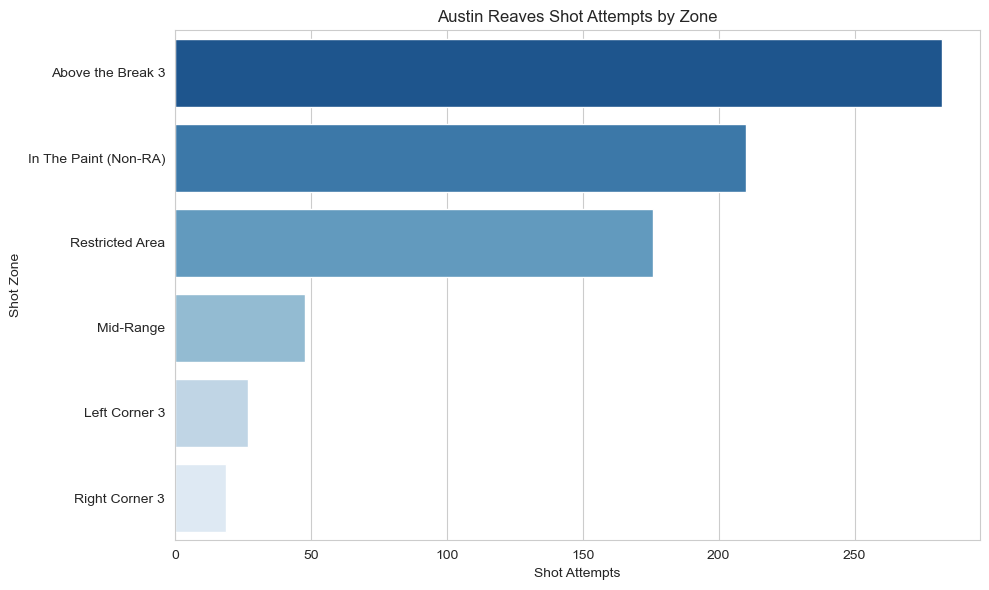

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_summary,
    x='attempts',
    y='SHOT_ZONE_BASIC',
    hue='SHOT_ZONE_BASIC',
    palette='Blues_r',
    legend=False
)

plt.title('Austin Reaves Shot Attempts by Zone')
plt.xlabel('Shot Attempts')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

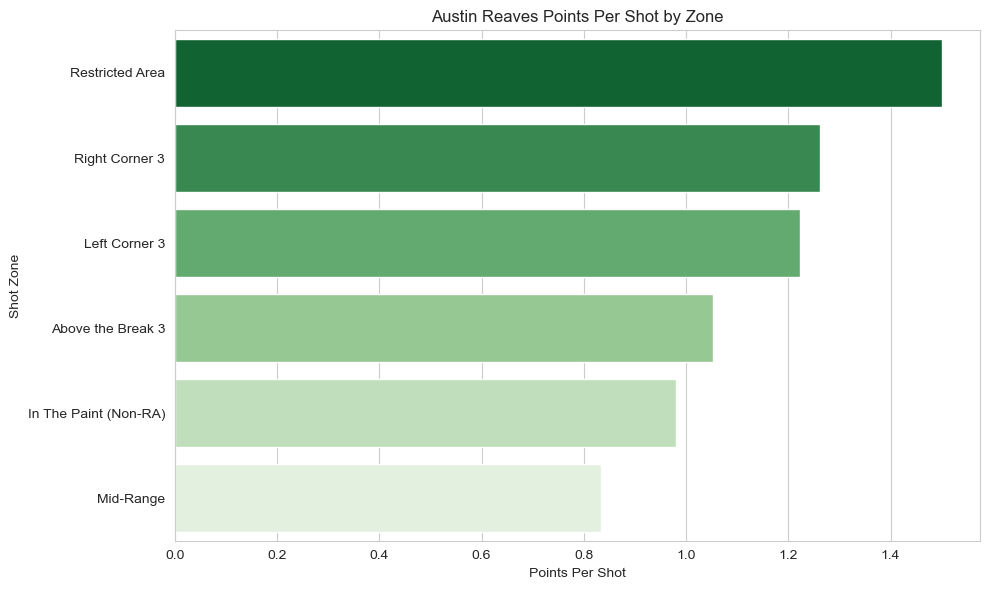

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_summary.sort_values('points_per_shot', ascending=False),
    x='points_per_shot',
    y='SHOT_ZONE_BASIC',
    hue='SHOT_ZONE_BASIC',
    palette='Greens_r',
    legend=False
)

plt.title('Austin Reaves Points Per Shot by Zone')
plt.xlabel('Points Per Shot')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

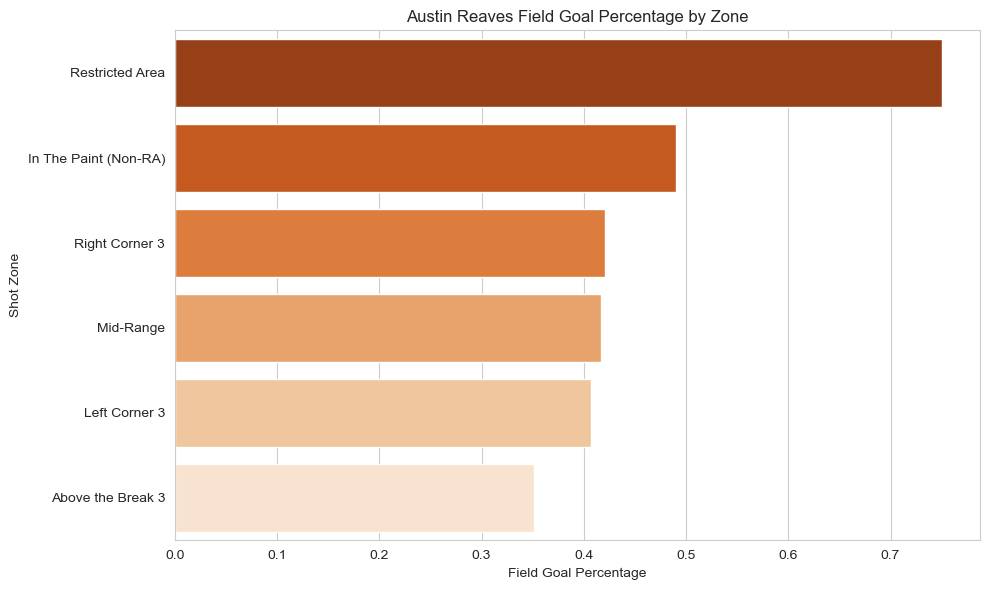

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_summary.sort_values('FG%', ascending=False),
    x='FG%',
    y='SHOT_ZONE_BASIC',
    hue='SHOT_ZONE_BASIC',
    palette='Oranges_r',
    legend=False
)

plt.title('Austin Reaves Field Goal Percentage by Zone')
plt.xlabel('Field Goal Percentage')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

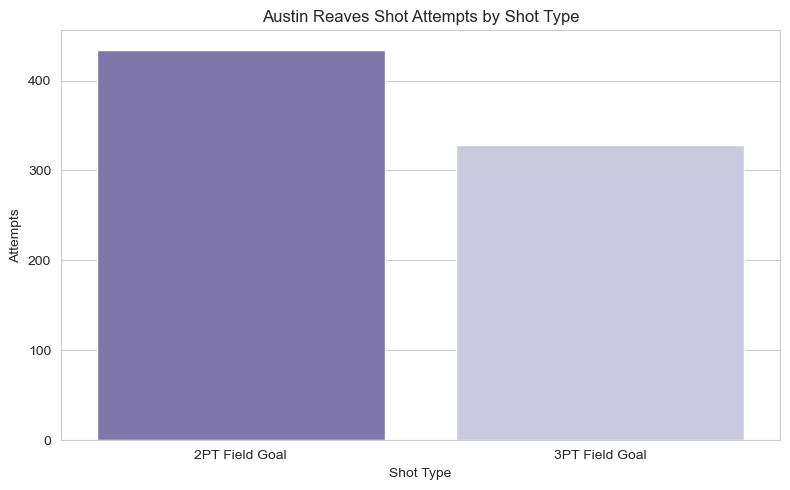

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=shot_type_summary,
    x='SHOT_TYPE',
    y='attempts',
    hue='SHOT_TYPE',
    palette='Purples_r',
    legend=False
)

plt.title('Austin Reaves Shot Attempts by Shot Type')
plt.xlabel('Shot Type')
plt.ylabel('Attempts')
plt.tight_layout()
plt.show()

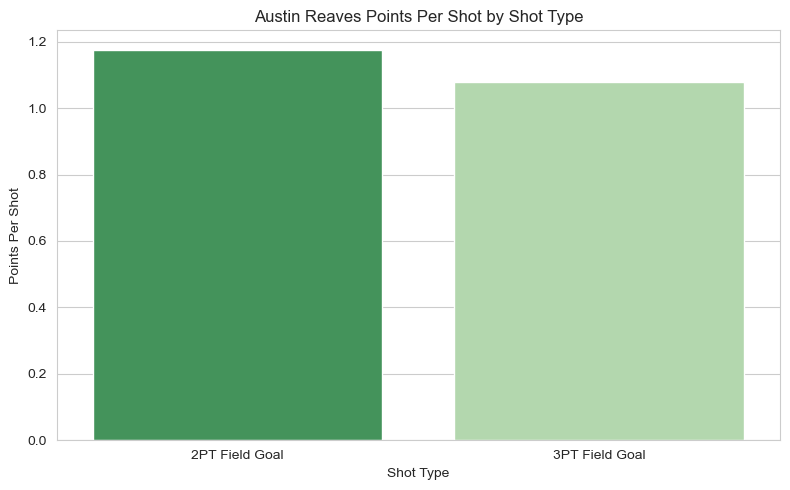

In [39]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=shot_type_summary,
    x='SHOT_TYPE',
    y='points_per_shot',
    hue='SHOT_TYPE',
    palette='Greens_r',
    legend=False
)

plt.title('Austin Reaves Points Per Shot by Shot Type')
plt.xlabel('Shot Type')
plt.ylabel('Points Per Shot')
plt.tight_layout()
plt.show()

In [41]:
df.columns

Index(['GRID_TYPE', 'GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME',
       'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING',
       'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE',
       'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE',
       'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE',
       'HTM', 'VTM'],
      dtype='object')

In [42]:
df.head()

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM
0,Shot Chart Detail,0022500002,14,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,10,39,...,Center(C),Less Than 8 ft.,3,-13,32,1,1,20251021,LAL,GSW
1,Shot Chart Detail,0022500002,67,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,6,12,...,Center(C),Less Than 8 ft.,2,27,7,1,0,20251021,LAL,GSW
2,Shot Chart Detail,0022500002,74,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,5,46,...,Center(C),24+ ft.,26,-38,267,1,0,20251021,LAL,GSW
3,Shot Chart Detail,0022500002,164,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,0,37,...,Center(C),Less Than 8 ft.,1,4,17,1,1,20251021,LAL,GSW
4,Shot Chart Detail,0022500002,182,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,0,0,...,Left Side Center(LC),24+ ft.,26,-184,190,1,0,20251021,LAL,GSW


In [43]:
# Make a copy of the raw shot data
reaves_shots = df.copy()

# If your dataframe includes multiple players, filter to Austin Reaves
if 'PLAYER_NAME' in reaves_shots.columns:
    reaves_shots = reaves_shots[reaves_shots['PLAYER_NAME'] == 'Austin Reaves'].copy()

# Convert date
reaves_shots['GAME_DATE'] = pd.to_datetime(reaves_shots['GAME_DATE'])

# Standardize made/missed
reaves_shots['made'] = reaves_shots['SHOT_MADE_FLAG'].astype(int)

# Assign shot value: 3 for 3PT shots, 2 for 2PT shots
reaves_shots['shot_value'] = reaves_shots['SHOT_TYPE'].apply(
    lambda x: 3 if '3PT' in x else 2
)

# Actual points from each shot
reaves_shots['actual_points'] = reaves_shots['made'] * reaves_shots['shot_value']

# Time remaining in period
reaves_shots['seconds_remaining'] = (
    reaves_shots['MINUTES_REMAINING'] * 60 + reaves_shots['SECONDS_REMAINING']
)

# Remove bad/missing coordinate rows
reaves_shots = reaves_shots.dropna(
    subset=['LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'SHOT_TYPE', 'SHOT_ZONE_BASIC', 'made']
)

reaves_shots.head()

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,made,shot_value,actual_points,seconds_remaining
0,Shot Chart Detail,0022500002,14,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,10,39,...,32,1,1,2025-10-21,LAL,GSW,1,2,2,639
1,Shot Chart Detail,0022500002,67,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,6,12,...,7,1,0,2025-10-21,LAL,GSW,0,2,0,372
2,Shot Chart Detail,0022500002,74,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,5,46,...,267,1,0,2025-10-21,LAL,GSW,0,3,0,346
3,Shot Chart Detail,0022500002,164,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,0,37,...,17,1,1,2025-10-21,LAL,GSW,1,2,2,37
4,Shot Chart Detail,0022500002,182,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,0,0,...,190,1,0,2025-10-21,LAL,GSW,0,3,0,0


In [44]:
reaves_shots[
    [
        'GAME_DATE',
        'LOC_X',
        'LOC_Y',
        'SHOT_TYPE',
        'ACTION_TYPE',
        'SHOT_ZONE_BASIC',
        'SHOT_ZONE_AREA',
        'SHOT_ZONE_RANGE',
        'SHOT_DISTANCE',
        'made',
        'actual_points',
        'PERIOD',
        'seconds_remaining'
    ]
].head()

,GAME_DATE,LOC_X,LOC_Y,SHOT_TYPE,ACTION_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,made,actual_points,PERIOD,seconds_remaining
0,2025-10-21,-13,32,2PT Field Goal,Driving Finger Roll Layup Shot,Restricted Area,Center(C),Less Than 8 ft.,3,1,2,1,639
1,2025-10-21,27,7,2PT Field Goal,Running Layup Shot,Restricted Area,Center(C),Less Than 8 ft.,2,0,0,1,372
2,2025-10-21,-38,267,3PT Field Goal,Jump Shot,Above the Break 3,Center(C),24+ ft.,26,0,0,1,346
3,2025-10-21,4,17,2PT Field Goal,Driving Finger Roll Layup Shot,Restricted Area,Center(C),Less Than 8 ft.,1,1,2,1,37
4,2025-10-21,-184,190,3PT Field Goal,Pullup Jump shot,Above the Break 3,Left Side Center(LC),24+ ft.,26,0,0,1,0


In [45]:
reaves_shots['shot_zone'] = (
    reaves_shots['SHOT_ZONE_BASIC'].astype(str) + ' - ' +
    reaves_shots['SHOT_ZONE_AREA'].astype(str)
)

reaves_shots[['SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'shot_zone']].head()

,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,shot_zone
0,Restricted Area,Center(C),Restricted Area - Center(C)
1,Restricted Area,Center(C),Restricted Area - Center(C)
2,Above the Break 3,Center(C),Above the Break 3 - Center(C)
3,Restricted Area,Center(C),Restricted Area - Center(C)
4,Above the Break 3,Left Side Center(LC),Above the Break 3 - Left Side Center(LC)


In [46]:
zone_summary = (
    reaves_shots
    .groupby('shot_zone')
    .agg(
        attempts=('made', 'count'),
        makes=('made', 'sum'),
        fg_pct=('made', 'mean'),
        points=('actual_points', 'sum'),
        points_per_shot=('actual_points', 'mean'),
        avg_distance=('SHOT_DISTANCE', 'mean')
    )
    .reset_index()
    .sort_values('attempts', ascending=False)
)

zone_summary

,shot_zone,attempts,makes,fg_pct,points,points_per_shot,avg_distance
3,In The Paint (Non-RA) - Center(C),190,97,0.510526,194,1.021053,7.626316
12,Restricted Area - Center(C),176,132,0.750000,264,1.500000,2.000000
1,Above the Break 3 - Left Side Center(LC),119,45,0.378151,135,1.134454,26.184874
2,Above the Break 3 - Right Side Center(RC),83,26,0.313253,78,0.939759,26.036145
0,Above the Break 3 - Center(C),80,28,0.350000,84,1.050000,26.787500
6,Left Corner 3 - Left Side(L),27,11,0.407407,33,1.222222,22.925926
13,Right Corner 3 - Right Side(R),19,8,0.421053,24,1.263158,23.105263
7,Mid-Range - Center(C),14,8,0.571429,16,1.142857,15.000000
9,Mid-Range - Left Side(L),13,8,0.615385,16,1.230769,10.692308
4,In The Paint (Non-RA) - Left Side(L),11,4,0.363636,8,0.727273,9.818182


In [47]:
zone_summary_filtered = zone_summary[zone_summary['attempts'] >= 5].copy()

C:\Users\Rod\AppData\Local\Temp\ipykernel_32232\3552219829.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


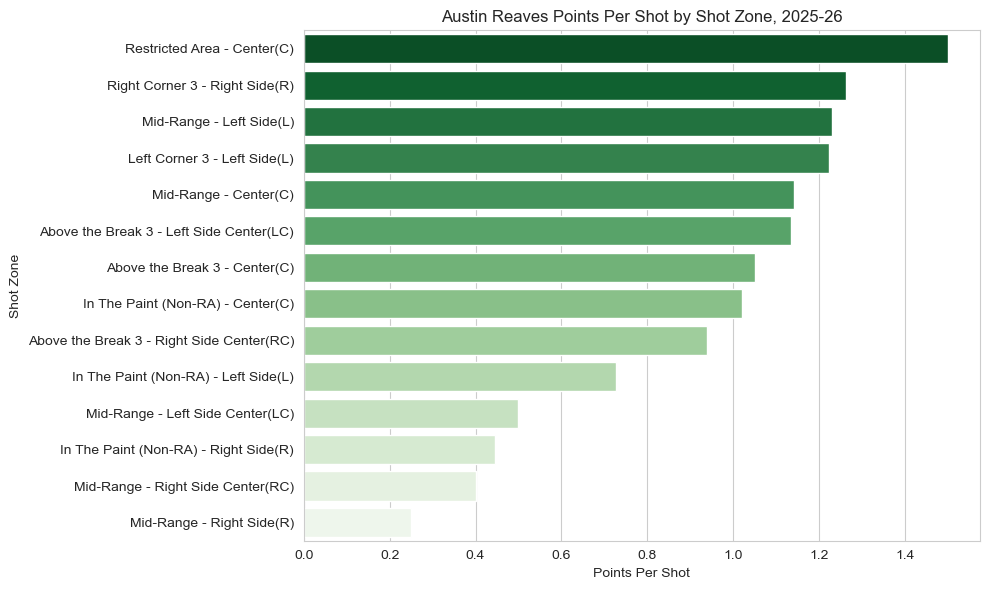

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_summary_filtered.sort_values('points_per_shot', ascending=False),
    x='points_per_shot',
    y='shot_zone',
    palette='Greens_r'
)

plt.title('Austin Reaves Points Per Shot by Shot Zone, 2025-26')
plt.xlabel('Points Per Shot')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

C:\Users\Rod\AppData\Local\Temp\ipykernel_32232\2139122848.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


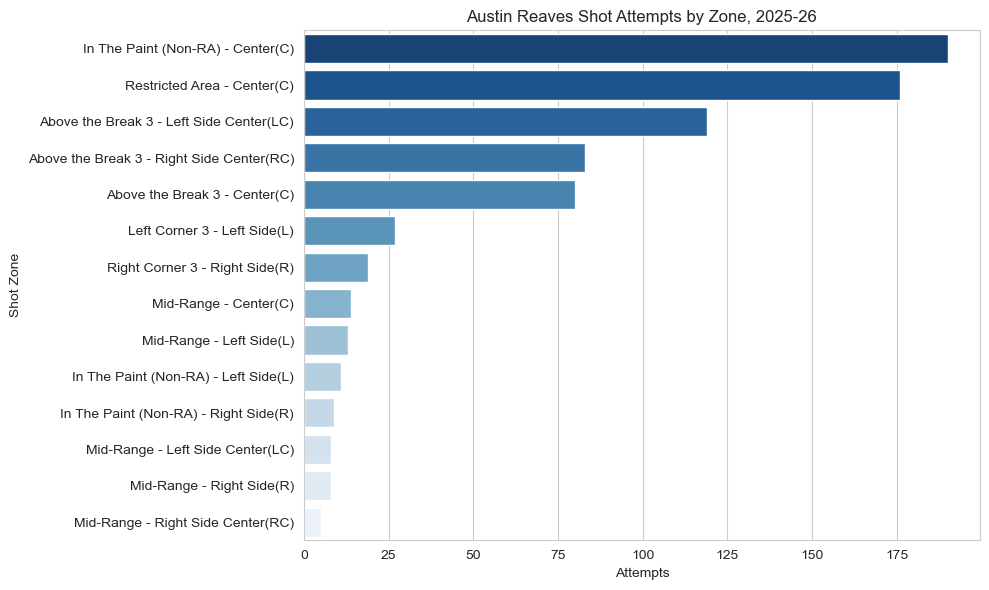

In [49]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_summary_filtered.sort_values('attempts', ascending=False),
    x='attempts',
    y='shot_zone',
    palette='Blues_r'
)

plt.title('Austin Reaves Shot Attempts by Zone, 2025-26')
plt.xlabel('Attempts')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

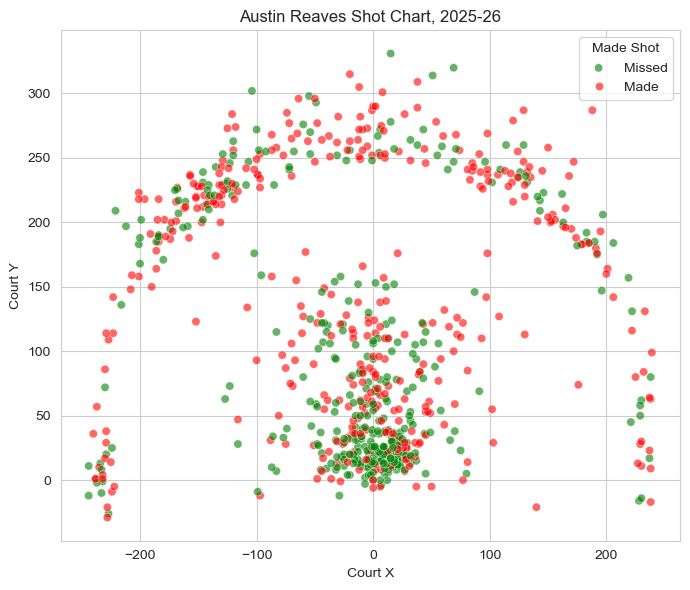

In [50]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=reaves_shots,
    x='LOC_X',
    y='LOC_Y',
    hue='made',
    palette={0: 'red', 1: 'green'},
    alpha=0.6
)

plt.title('Austin Reaves Shot Chart, 2025-26')
plt.xlabel('Court X')
plt.ylabel('Court Y')
plt.legend(title='Made Shot', labels=['Missed', 'Made'])
plt.tight_layout()
plt.show()

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

In [52]:
model_df = reaves_shots.copy()

features = [
    'SHOT_DISTANCE',
    'LOC_X',
    'LOC_Y',
    'SHOT_TYPE',
    'ACTION_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE',
    'PERIOD',
    'seconds_remaining'
]

target = 'made'

model_df = model_df.dropna(subset=features + [target])

In [53]:
numeric_features = [
    'SHOT_DISTANCE',
    'LOC_X',
    'LOC_Y',
    'PERIOD',
    'seconds_remaining'
]

categorical_features = [
    'SHOT_TYPE',
    'ACTION_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE'
]

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

shot_quality_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)

In [56]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

shot_quality_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SHOT_DISTANCE', 'LOC_X',
                                                   'LOC_Y', 'PERIOD',
                                                   'seconds_remaining']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SHOT_TYPE', 'ACTION_TYPE',
                                                   'SHOT_ZONE_BASIC',
                                                   'SHOT_ZONE_AREA',
                                                   'SHOT_ZONE_RANGE'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [57]:
test_probs = shot_quality_model.predict_proba(X_test)[:, 1]
test_preds = shot_quality_model.predict(X_test)

auc = roc_auc_score(y_test, test_probs)
accuracy = accuracy_score(y_test, test_preds)

print("AUC:", round(auc, 3))
print("Accuracy:", round(accuracy, 3))

AUC: 0.691
Accuracy: 0.649


In [58]:
reaves_shots['expected_make_prob'] = shot_quality_model.predict_proba(
    reaves_shots[features]
)[:, 1]

reaves_shots['expected_points'] = (
    reaves_shots['expected_make_prob'] * reaves_shots['shot_value']
)

reaves_shots['points_above_expected'] = (
    reaves_shots['actual_points'] - reaves_shots['expected_points']
)

reaves_shots[
    [
        'SHOT_TYPE',
        'ACTION_TYPE',
        'SHOT_DISTANCE',
        'made',
        'shot_value',
        'actual_points',
        'expected_make_prob',
        'expected_points',
        'points_above_expected'
    ]
].head()

,SHOT_TYPE,ACTION_TYPE,SHOT_DISTANCE,made,shot_value,actual_points,expected_make_prob,expected_points,points_above_expected
0,2PT Field Goal,Driving Finger Roll Layup Shot,3,1,2,2,0.662166,1.324332,0.675668
1,2PT Field Goal,Running Layup Shot,2,0,2,0,0.714199,1.428399,-1.428399
2,3PT Field Goal,Jump Shot,26,0,3,0,0.373017,1.119050,-1.119050
3,2PT Field Goal,Driving Finger Roll Layup Shot,1,1,2,2,0.697310,1.394620,0.605380
4,3PT Field Goal,Pullup Jump shot,26,0,3,0,0.244303,0.732910,-0.732910


In [59]:
shot_type_actual_expected = (
    reaves_shots
    .groupby('SHOT_TYPE')
    .agg(
        attempts=('made', 'count'),
        actual_points=('actual_points', 'sum'),
        expected_points=('expected_points', 'sum'),
        actual_pps=('actual_points', 'mean'),
        expected_pps=('expected_points', 'mean'),
        points_above_expected=('points_above_expected', 'sum')
    )
    .reset_index()
)

shot_type_actual_expected['pps_difference'] = (
    shot_type_actual_expected['actual_pps'] - shot_type_actual_expected['expected_pps']
)

shot_type_actual_expected

,SHOT_TYPE,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
0,2PT Field Goal,434,510,510.633360,1.175115,1.176575,-0.633360,-0.001459
1,3PT Field Goal,328,354,344.240149,1.079268,1.049513,9.759851,0.029756


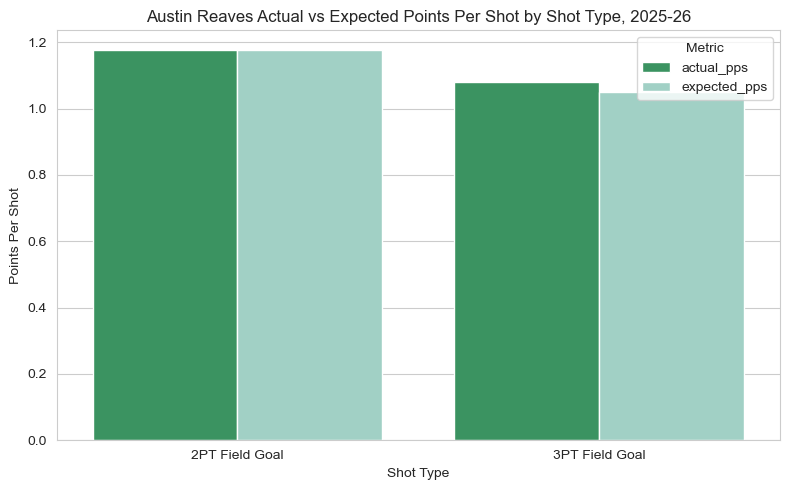

In [60]:
shot_type_plot = shot_type_actual_expected.melt(
    id_vars='SHOT_TYPE',
    value_vars=['actual_pps', 'expected_pps'],
    var_name='Metric',
    value_name='Points Per Shot'
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=shot_type_plot,
    x='SHOT_TYPE',
    y='Points Per Shot',
    hue='Metric',
    palette=['#2ca25f', '#99d8c9']
)

plt.title('Austin Reaves Actual vs Expected Points Per Shot by Shot Type, 2025-26')
plt.xlabel('Shot Type')
plt.ylabel('Points Per Shot')
plt.tight_layout()
plt.show()

In [61]:
zone_actual_expected = (
    reaves_shots
    .groupby('shot_zone')
    .agg(
        attempts=('made', 'count'),
        actual_points=('actual_points', 'sum'),
        expected_points=('expected_points', 'sum'),
        actual_pps=('actual_points', 'mean'),
        expected_pps=('expected_points', 'mean'),
        points_above_expected=('points_above_expected', 'sum')
    )
    .reset_index()
)

zone_actual_expected['pps_difference'] = (
    zone_actual_expected['actual_pps'] - zone_actual_expected['expected_pps']
)

zone_actual_expected = zone_actual_expected.sort_values(
    'points_above_expected',
    ascending=False
)

zone_actual_expected

,shot_zone,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
6,Left Corner 3 - Left Side(L),27,33,23.502761,1.222222,0.870473,9.497239,0.351750
1,Above the Break 3 - Left Side Center(LC),119,135,126.479091,1.134454,1.062850,8.520909,0.071604
12,Restricted Area - Center(C),176,264,257.534031,1.500000,1.463262,6.465969,0.036738
9,Mid-Range - Left Side(L),13,16,13.431379,1.230769,1.033183,2.568621,0.197586
7,Mid-Range - Center(C),14,16,13.817230,1.142857,0.986945,2.182770,0.155912
8,Mid-Range - Left Side Center(LC),8,4,4.724932,0.500000,0.590616,-0.724932,-0.090616
10,Mid-Range - Right Side Center(RC),5,2,2.826591,0.400000,0.565318,-0.826591,-0.165318
13,Right Corner 3 - Right Side(R),19,24,24.833085,1.263158,1.307004,-0.833085,-0.043847
5,In The Paint (Non-RA) - Right Side(R),9,4,5.183897,0.444444,0.575989,-1.183897,-0.131544
4,In The Paint (Non-RA) - Left Side(L),11,8,10.239284,0.727273,0.930844,-2.239284,-0.203571


In [62]:
zone_actual_expected_filtered = zone_actual_expected[
    zone_actual_expected['attempts'] >= 5
].copy()

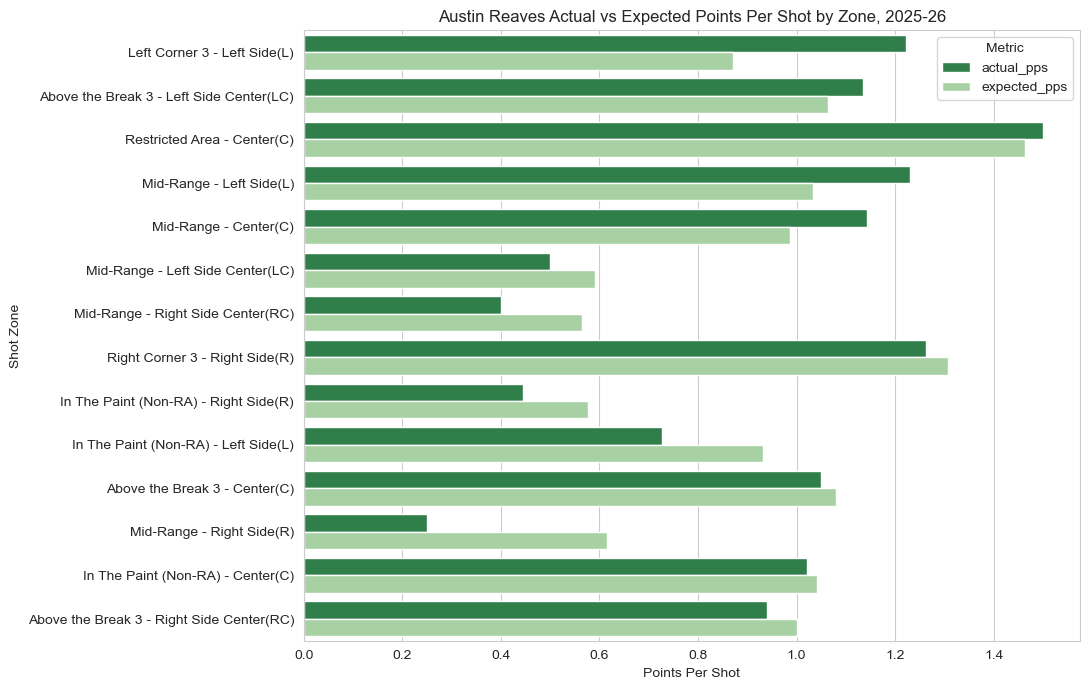

In [63]:
zone_plot = zone_actual_expected_filtered.melt(
    id_vars='shot_zone',
    value_vars=['actual_pps', 'expected_pps'],
    var_name='Metric',
    value_name='Points Per Shot'
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=zone_plot,
    x='Points Per Shot',
    y='shot_zone',
    hue='Metric',
    palette=['#238b45', '#a1d99b']
)

plt.title('Austin Reaves Actual vs Expected Points Per Shot by Zone, 2025-26')
plt.xlabel('Points Per Shot')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

C:\Users\Rod\AppData\Local\Temp\ipykernel_32232\573555944.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


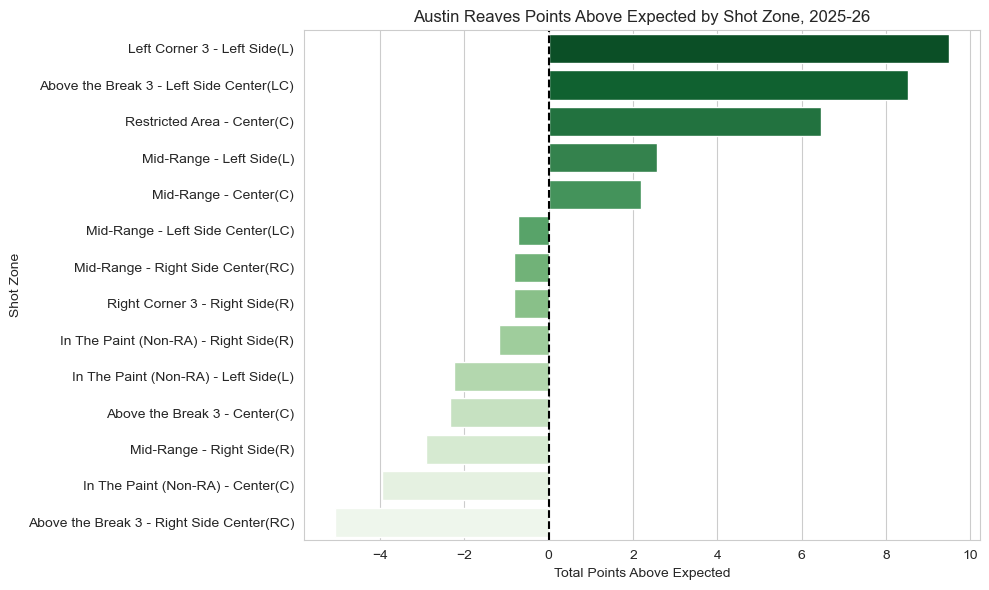

In [64]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_actual_expected_filtered.sort_values('points_above_expected', ascending=False),
    x='points_above_expected',
    y='shot_zone',
    palette='Greens_r'
)

plt.axvline(0, color='black', linestyle='--')

plt.title('Austin Reaves Points Above Expected by Shot Zone, 2025-26')
plt.xlabel('Total Points Above Expected')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

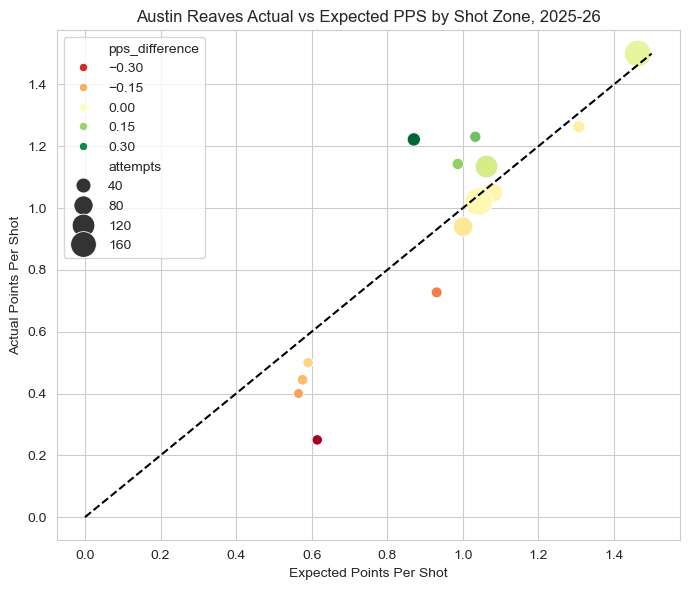

In [65]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=zone_actual_expected_filtered,
    x='expected_pps',
    y='actual_pps',
    size='attempts',
    hue='pps_difference',
    palette='RdYlGn',
    sizes=(50, 400)
)

max_val = max(
    zone_actual_expected_filtered['expected_pps'].max(),
    zone_actual_expected_filtered['actual_pps'].max()
)

plt.plot([0, max_val], [0, max_val], color='black', linestyle='--')

plt.title('Austin Reaves Actual vs Expected PPS by Shot Zone, 2025-26')
plt.xlabel('Expected Points Per Shot')
plt.ylabel('Actual Points Per Shot')
plt.tight_layout()
plt.show()

In [66]:
final_zone_table = zone_actual_expected_filtered[
    [
        'shot_zone',
        'attempts',
        'actual_pps',
        'expected_pps',
        'pps_difference',
        'points_above_expected'
    ]
].sort_values('points_above_expected', ascending=False)

final_zone_table

,shot_zone,attempts,actual_pps,expected_pps,pps_difference,points_above_expected
6,Left Corner 3 - Left Side(L),27,1.222222,0.870473,0.351750,9.497239
1,Above the Break 3 - Left Side Center(LC),119,1.134454,1.062850,0.071604,8.520909
12,Restricted Area - Center(C),176,1.500000,1.463262,0.036738,6.465969
9,Mid-Range - Left Side(L),13,1.230769,1.033183,0.197586,2.568621
7,Mid-Range - Center(C),14,1.142857,0.986945,0.155912,2.182770
8,Mid-Range - Left Side Center(LC),8,0.500000,0.590616,-0.090616,-0.724932
10,Mid-Range - Right Side Center(RC),5,0.400000,0.565318,-0.165318,-0.826591
13,Right Corner 3 - Right Side(R),19,1.263158,1.307004,-0.043847,-0.833085
5,In The Paint (Non-RA) - Right Side(R),9,0.444444,0.575989,-0.131544,-1.183897
4,In The Paint (Non-RA) - Left Side(L),11,0.727273,0.930844,-0.203571,-2.239284


In [67]:
final_zone_table_rounded = final_zone_table.copy()

cols_to_round = [
    'actual_pps',
    'expected_pps',
    'pps_difference',
    'points_above_expected'
]

final_zone_table_rounded[cols_to_round] = final_zone_table_rounded[cols_to_round].round(3)

final_zone_table_rounded

,shot_zone,attempts,actual_pps,expected_pps,pps_difference,points_above_expected
6,Left Corner 3 - Left Side(L),27,1.222,0.870,0.352,9.497
1,Above the Break 3 - Left Side Center(LC),119,1.134,1.063,0.072,8.521
12,Restricted Area - Center(C),176,1.500,1.463,0.037,6.466
9,Mid-Range - Left Side(L),13,1.231,1.033,0.198,2.569
7,Mid-Range - Center(C),14,1.143,0.987,0.156,2.183
8,Mid-Range - Left Side Center(LC),8,0.500,0.591,-0.091,-0.725
10,Mid-Range - Right Side Center(RC),5,0.400,0.565,-0.165,-0.827
13,Right Corner 3 - Right Side(R),19,1.263,1.307,-0.044,-0.833
5,In The Paint (Non-RA) - Right Side(R),9,0.444,0.576,-0.132,-1.184
4,In The Paint (Non-RA) - Left Side(L),11,0.727,0.931,-0.204,-2.239


In [ ]:
## Roster Context and Role Fit

Because Austin Reaves’ role may change depending on the Lakers’ roster construction, this section evaluates how his shot profile could translate across different offensive contexts. Rather than viewing his scoring efficiency in isolation, I use the shot value results to assess whether his strengths are scalable next to higher-usage stars or in a sixth-man role.

In [ ]:
### Scalability Indicators

Reaves’ positive three-point points above expected is an important scalability signal. Players who can add value from three and attack closeouts tend to fit more easily next to high-usage stars because they do not need every possession to be built around them. Reaves also produced strong value in the restricted area, suggesting he can convert advantage situations into efficient rim attempts.

In [68]:
# Create a cleaner shot zone label
reaves_shots['shot_zone'] = (
    reaves_shots['SHOT_ZONE_BASIC'].astype(str) + ' - ' +
    reaves_shots['SHOT_ZONE_AREA'].astype(str)
)

zone_summary = (
    reaves_shots
    .groupby('shot_zone')
    .agg(
        attempts=('SHOT_MADE_FLAG', 'count'),
        makes=('SHOT_MADE_FLAG', 'sum'),
        fg_pct=('SHOT_MADE_FLAG', 'mean'),
        points=('actual_points', 'sum'),
        points_per_shot=('actual_points', 'mean'),
        avg_distance=('SHOT_DISTANCE', 'mean')
    )
    .reset_index()
    .sort_values('attempts', ascending=False)
)

zone_summary

,shot_zone,attempts,makes,fg_pct,points,points_per_shot,avg_distance
3,In The Paint (Non-RA) - Center(C),190,97,0.510526,194,1.021053,7.626316
12,Restricted Area - Center(C),176,132,0.750000,264,1.500000,2.000000
1,Above the Break 3 - Left Side Center(LC),119,45,0.378151,135,1.134454,26.184874
2,Above the Break 3 - Right Side Center(RC),83,26,0.313253,78,0.939759,26.036145
0,Above the Break 3 - Center(C),80,28,0.350000,84,1.050000,26.787500
6,Left Corner 3 - Left Side(L),27,11,0.407407,33,1.222222,22.925926
13,Right Corner 3 - Right Side(R),19,8,0.421053,24,1.263158,23.105263
7,Mid-Range - Center(C),14,8,0.571429,16,1.142857,15.000000
9,Mid-Range - Left Side(L),13,8,0.615385,16,1.230769,10.692308
4,In The Paint (Non-RA) - Left Side(L),11,4,0.363636,8,0.727273,9.818182


In [69]:
reaves_shots['made'] = reaves_shots['SHOT_MADE_FLAG'].astype(int)

reaves_shots['shot_value'] = reaves_shots['SHOT_TYPE'].apply(
    lambda x: 3 if '3PT' in x else 2
)

reaves_shots['actual_points'] = reaves_shots['made'] * reaves_shots['shot_value']

C:\Users\Rod\AppData\Local\Temp\ipykernel_32232\3626506302.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


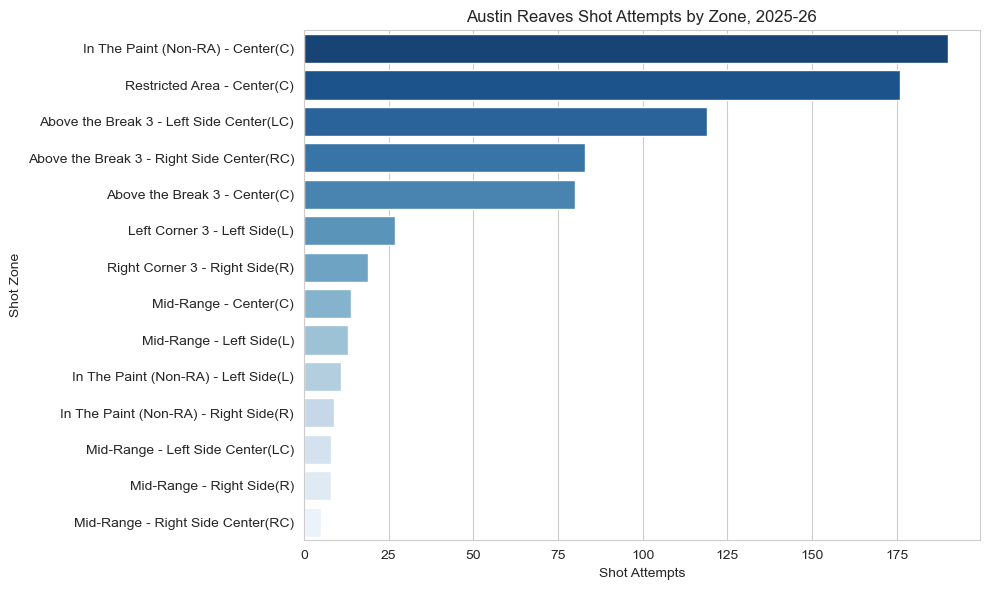

In [70]:
zone_summary_filtered = zone_summary[zone_summary['attempts'] >= 5].copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_summary_filtered.sort_values('attempts', ascending=False),
    x='attempts',
    y='shot_zone',
    palette='Blues_r'
)

plt.title('Austin Reaves Shot Attempts by Zone, 2025-26')
plt.xlabel('Shot Attempts')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

C:\Users\Rod\AppData\Local\Temp\ipykernel_32232\1588323378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


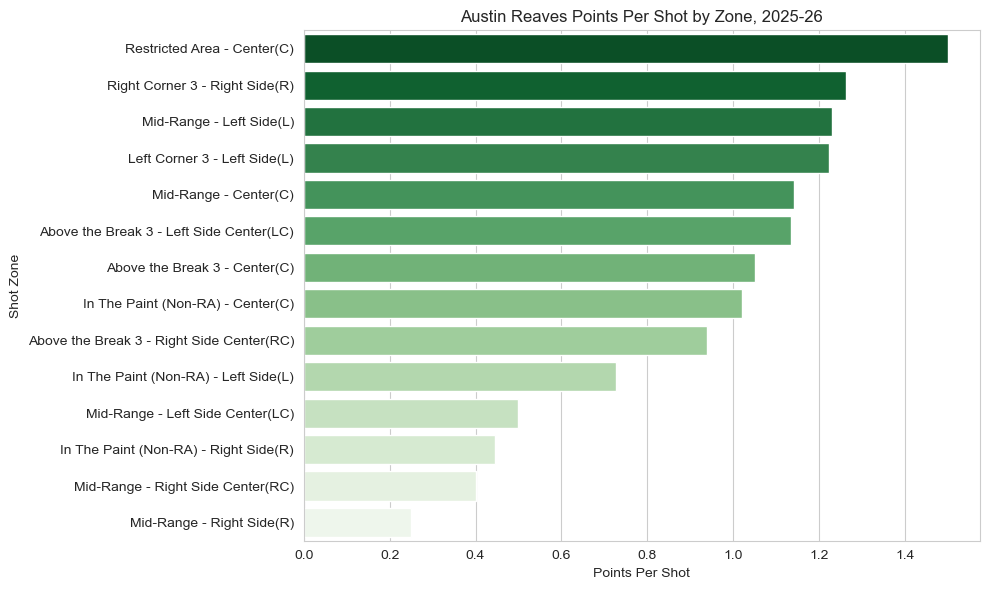

In [71]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_summary_filtered.sort_values('points_per_shot', ascending=False),
    x='points_per_shot',
    y='shot_zone',
    palette='Greens_r'
)

plt.title('Austin Reaves Points Per Shot by Zone, 2025-26')
plt.xlabel('Points Per Shot')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

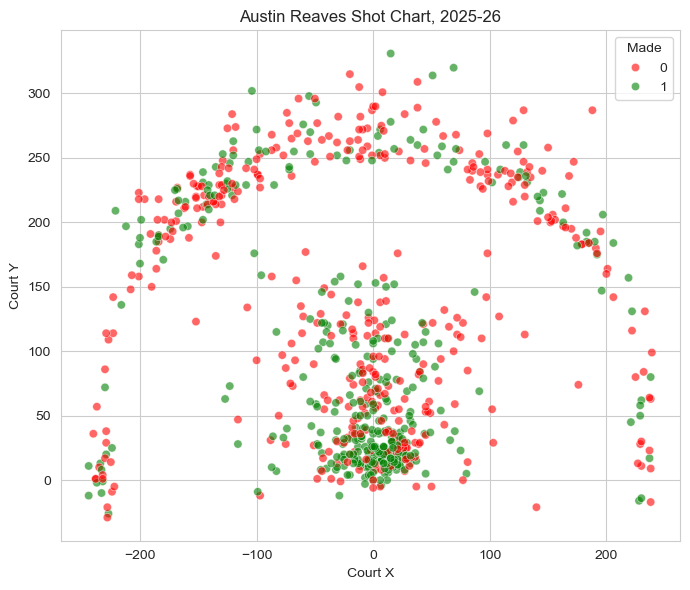

In [73]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=reaves_shots,
    x='LOC_X',
    y='LOC_Y',
    hue='made',
    palette={0: 'red', 1: 'green'},
    alpha=0.6
)

plt.title('Austin Reaves Shot Chart, 2025-26')
plt.xlabel('Court X')
plt.ylabel('Court Y')
plt.legend(title='Made')
plt.tight_layout()
plt.show()

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

In [75]:
reaves_shots['seconds_remaining'] = (
    reaves_shots['MINUTES_REMAINING'] * 60 +
    reaves_shots['SECONDS_REMAINING']
)

In [76]:
features = [
    'SHOT_DISTANCE',
    'LOC_X',
    'LOC_Y',
    'SHOT_TYPE',
    'ACTION_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE',
    'PERIOD',
    'seconds_remaining'
]

target = 'made'

model_df = reaves_shots.dropna(subset=features + [target]).copy()

In [77]:
numeric_features = [
    'SHOT_DISTANCE',
    'LOC_X',
    'LOC_Y',
    'PERIOD',
    'seconds_remaining'
]

categorical_features = [
    'SHOT_TYPE',
    'ACTION_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE'
]

In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

shot_quality_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

shot_quality_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SHOT_DISTANCE', 'LOC_X',
                                                   'LOC_Y', 'PERIOD',
                                                   'seconds_remaining']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SHOT_TYPE', 'ACTION_TYPE',
                                                   'SHOT_ZONE_BASIC',
                                                   'SHOT_ZONE_AREA',
                                                   'SHOT_ZONE_RANGE'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [79]:
reaves_shots['expected_make_prob'] = shot_quality_model.predict_proba(
    reaves_shots[features]
)[:, 1]

reaves_shots['expected_points'] = (
    reaves_shots['expected_make_prob'] * reaves_shots['shot_value']
)

reaves_shots['points_above_expected'] = (
    reaves_shots['actual_points'] - reaves_shots['expected_points']
)

In [80]:
shot_type_expected = (
    reaves_shots
    .groupby('SHOT_TYPE')
    .agg(
        attempts=('made', 'count'),
        actual_points=('actual_points', 'sum'),
        expected_points=('expected_points', 'sum'),
        actual_pps=('actual_points', 'mean'),
        expected_pps=('expected_points', 'mean'),
        points_above_expected=('points_above_expected', 'sum')
    )
    .reset_index()
)

shot_type_expected['pps_difference'] = (
    shot_type_expected['actual_pps'] - shot_type_expected['expected_pps']
)

shot_type_expected

,SHOT_TYPE,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
0,2PT Field Goal,434,510,510.633360,1.175115,1.176575,-0.633360,-0.001459
1,3PT Field Goal,328,354,344.240149,1.079268,1.049513,9.759851,0.029756


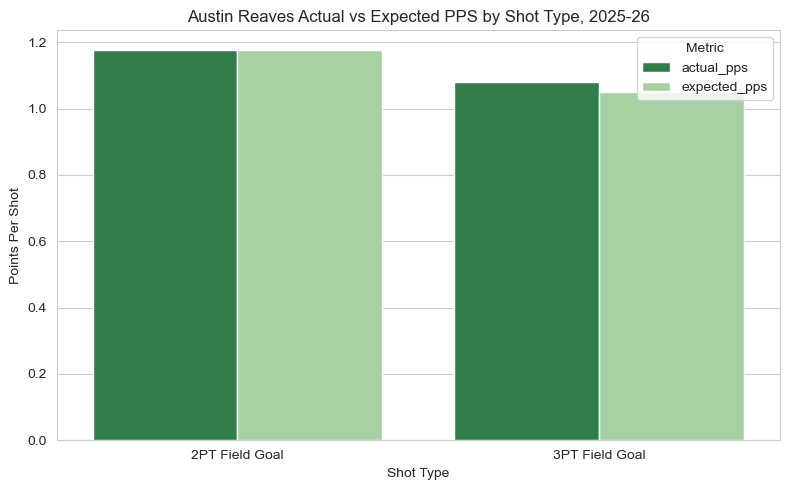

In [81]:
shot_type_plot = shot_type_expected.melt(
    id_vars='SHOT_TYPE',
    value_vars=['actual_pps', 'expected_pps'],
    var_name='Metric',
    value_name='Points Per Shot'
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=shot_type_plot,
    x='SHOT_TYPE',
    y='Points Per Shot',
    hue='Metric',
    palette=['#238b45', '#a1d99b']
)

plt.title('Austin Reaves Actual vs Expected PPS by Shot Type, 2025-26')
plt.xlabel('Shot Type')
plt.ylabel('Points Per Shot')
plt.tight_layout()
plt.show()

In [82]:
zone_expected = (
    reaves_shots
    .groupby('shot_zone')
    .agg(
        attempts=('made', 'count'),
        actual_points=('actual_points', 'sum'),
        expected_points=('expected_points', 'sum'),
        actual_pps=('actual_points', 'mean'),
        expected_pps=('expected_points', 'mean'),
        points_above_expected=('points_above_expected', 'sum')
    )
    .reset_index()
)

zone_expected['pps_difference'] = (
    zone_expected['actual_pps'] - zone_expected['expected_pps']
)

zone_expected_filtered = zone_expected[zone_expected['attempts'] >= 5].copy()

zone_expected_filtered.sort_values('points_above_expected', ascending=False)

,shot_zone,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
6,Left Corner 3 - Left Side(L),27,33,23.502761,1.222222,0.870473,9.497239,0.351750
1,Above the Break 3 - Left Side Center(LC),119,135,126.479091,1.134454,1.062850,8.520909,0.071604
12,Restricted Area - Center(C),176,264,257.534031,1.500000,1.463262,6.465969,0.036738
9,Mid-Range - Left Side(L),13,16,13.431379,1.230769,1.033183,2.568621,0.197586
7,Mid-Range - Center(C),14,16,13.817230,1.142857,0.986945,2.182770,0.155912
8,Mid-Range - Left Side Center(LC),8,4,4.724932,0.500000,0.590616,-0.724932,-0.090616
10,Mid-Range - Right Side Center(RC),5,2,2.826591,0.400000,0.565318,-0.826591,-0.165318
13,Right Corner 3 - Right Side(R),19,24,24.833085,1.263158,1.307004,-0.833085,-0.043847
5,In The Paint (Non-RA) - Right Side(R),9,4,5.183897,0.444444,0.575989,-1.183897,-0.131544
4,In The Paint (Non-RA) - Left Side(L),11,8,10.239284,0.727273,0.930844,-2.239284,-0.203571


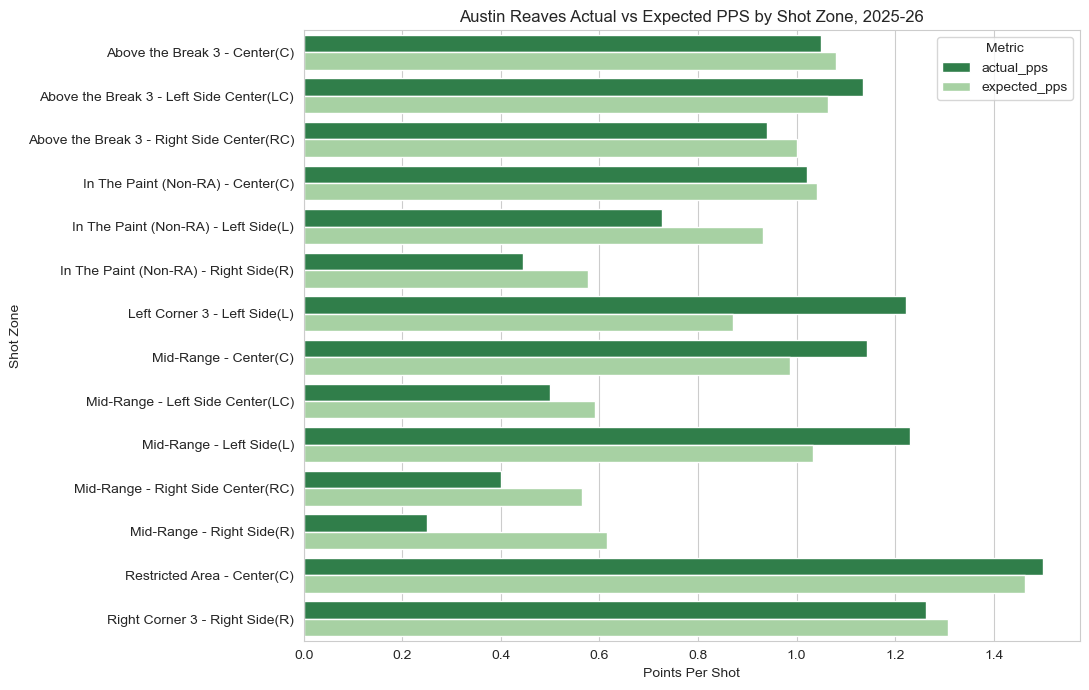

In [83]:
zone_plot = zone_expected_filtered.melt(
    id_vars='shot_zone',
    value_vars=['actual_pps', 'expected_pps'],
    var_name='Metric',
    value_name='Points Per Shot'
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=zone_plot,
    x='Points Per Shot',
    y='shot_zone',
    hue='Metric',
    palette=['#238b45', '#a1d99b']
)

plt.title('Austin Reaves Actual vs Expected PPS by Shot Zone, 2025-26')
plt.xlabel('Points Per Shot')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

C:\Users\Rod\AppData\Local\Temp\ipykernel_32232\3451912179.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


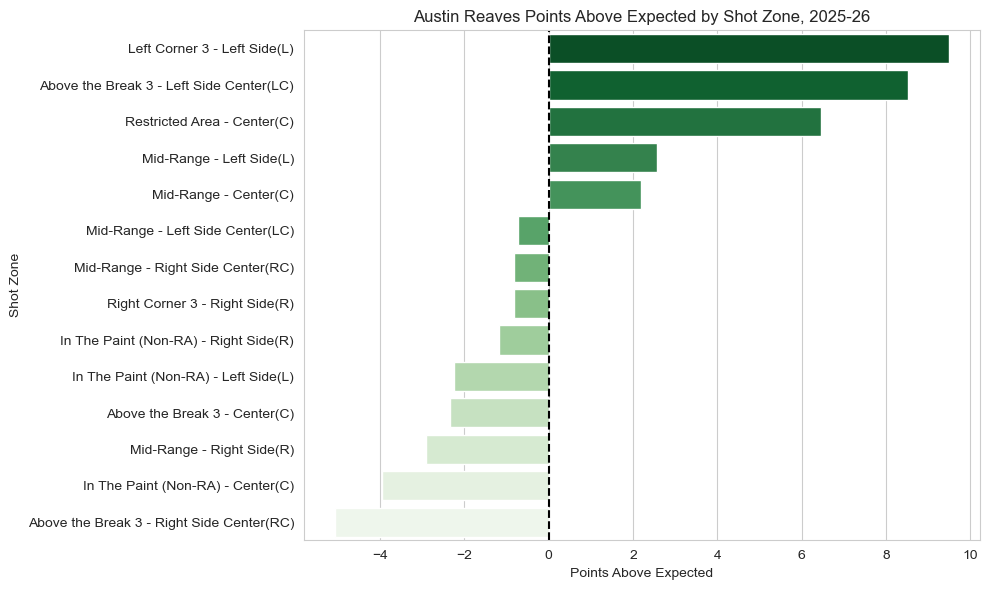

In [84]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_expected_filtered.sort_values('points_above_expected', ascending=False),
    x='points_above_expected',
    y='shot_zone',
    palette='Greens_r'
)

plt.axvline(0, color='black', linestyle='--')

plt.title('Austin Reaves Points Above Expected by Shot Zone, 2025-26')
plt.xlabel('Points Above Expected')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

In [85]:
reaves_shots.columns

Index(['GRID_TYPE', 'GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME',
       'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING',
       'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE',
       'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE',
       'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE',
       'HTM', 'VTM', 'made', 'shot_value', 'actual_points',
       'seconds_remaining', 'shot_zone', 'expected_make_prob',
       'expected_points', 'points_above_expected'],
      dtype='object')

In [86]:
# Standardize made/missed
reaves_shots['made'] = reaves_shots['SHOT_MADE_FLAG'].astype(int)

# Shot value: 3 for threes, 2 for twos
reaves_shots['shot_value'] = reaves_shots['SHOT_TYPE'].apply(
    lambda x: 3 if '3PT' in x else 2
)

# Actual points from each shot
reaves_shots['actual_points'] = reaves_shots['made'] * reaves_shots['shot_value']

# Create a cleaner zone label
reaves_shots['shot_zone'] = (
    reaves_shots['SHOT_ZONE_BASIC'].astype(str) + ' - ' +
    reaves_shots['SHOT_ZONE_AREA'].astype(str)
)

In [87]:
zone_summary = (
    reaves_shots
    .groupby('shot_zone')
    .agg(
        attempts=('made', 'count'),
        makes=('made', 'sum'),
        fg_pct=('made', 'mean'),
        points=('actual_points', 'sum'),
        points_per_shot=('actual_points', 'mean'),
        avg_distance=('SHOT_DISTANCE', 'mean')
    )
    .reset_index()
    .sort_values('attempts', ascending=False)
)

zone_summary

,shot_zone,attempts,makes,fg_pct,points,points_per_shot,avg_distance
3,In The Paint (Non-RA) - Center(C),190,97,0.510526,194,1.021053,7.626316
12,Restricted Area - Center(C),176,132,0.750000,264,1.500000,2.000000
1,Above the Break 3 - Left Side Center(LC),119,45,0.378151,135,1.134454,26.184874
2,Above the Break 3 - Right Side Center(RC),83,26,0.313253,78,0.939759,26.036145
0,Above the Break 3 - Center(C),80,28,0.350000,84,1.050000,26.787500
6,Left Corner 3 - Left Side(L),27,11,0.407407,33,1.222222,22.925926
13,Right Corner 3 - Right Side(R),19,8,0.421053,24,1.263158,23.105263
7,Mid-Range - Center(C),14,8,0.571429,16,1.142857,15.000000
9,Mid-Range - Left Side(L),13,8,0.615385,16,1.230769,10.692308
4,In The Paint (Non-RA) - Left Side(L),11,4,0.363636,8,0.727273,9.818182


In [88]:
zone_summary_filtered = zone_summary[zone_summary['attempts'] >= 5].copy()

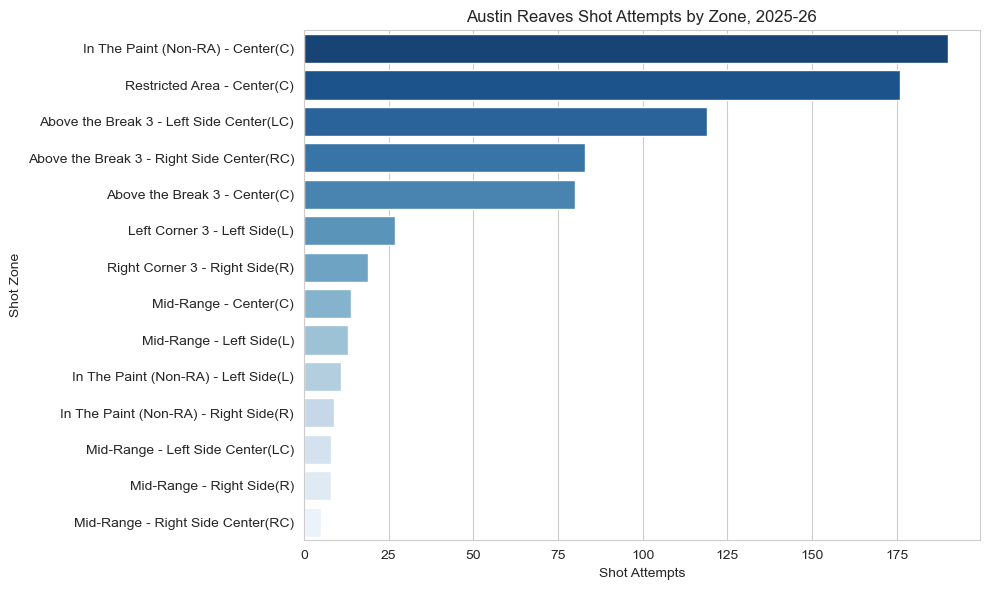

In [89]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_summary_filtered.sort_values('attempts', ascending=False),
    x='attempts',
    y='shot_zone',
    hue='shot_zone',
    palette='Blues_r',
    legend=False
)

plt.title('Austin Reaves Shot Attempts by Zone, 2025-26')
plt.xlabel('Shot Attempts')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

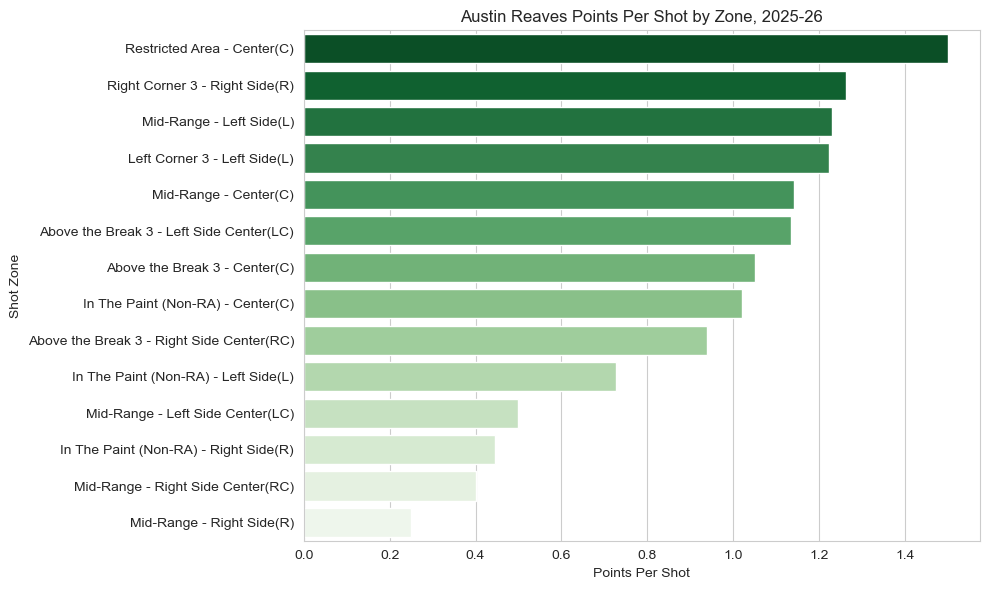

In [90]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_summary_filtered.sort_values('points_per_shot', ascending=False),
    x='points_per_shot',
    y='shot_zone',
    hue='shot_zone',
    palette='Greens_r',
    legend=False
)

plt.title('Austin Reaves Points Per Shot by Zone, 2025-26')
plt.xlabel('Points Per Shot')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

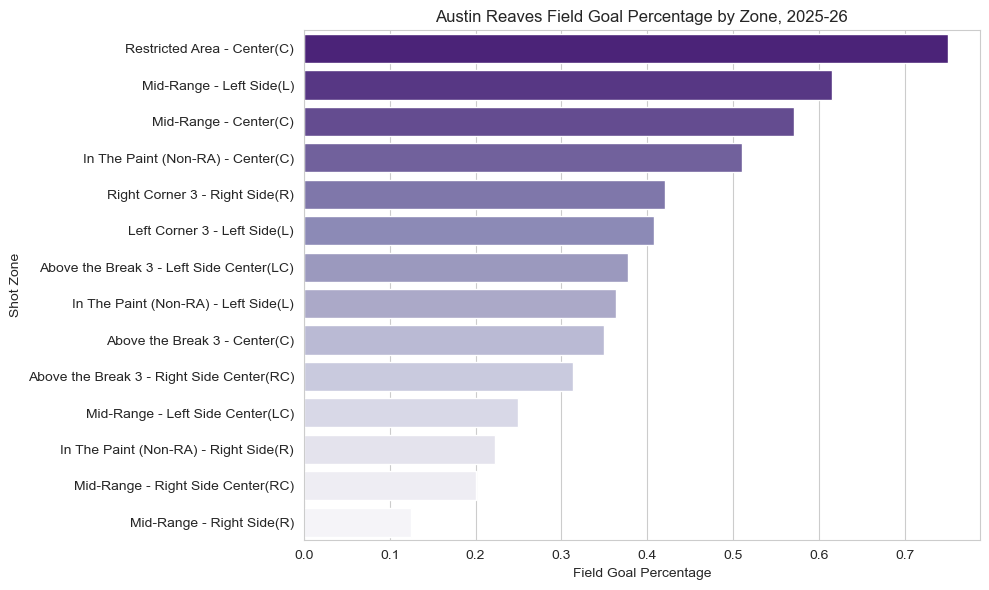

In [91]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_summary_filtered.sort_values('fg_pct', ascending=False),
    x='fg_pct',
    y='shot_zone',
    hue='shot_zone',
    palette='Purples_r',
    legend=False
)

plt.title('Austin Reaves Field Goal Percentage by Zone, 2025-26')
plt.xlabel('Field Goal Percentage')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

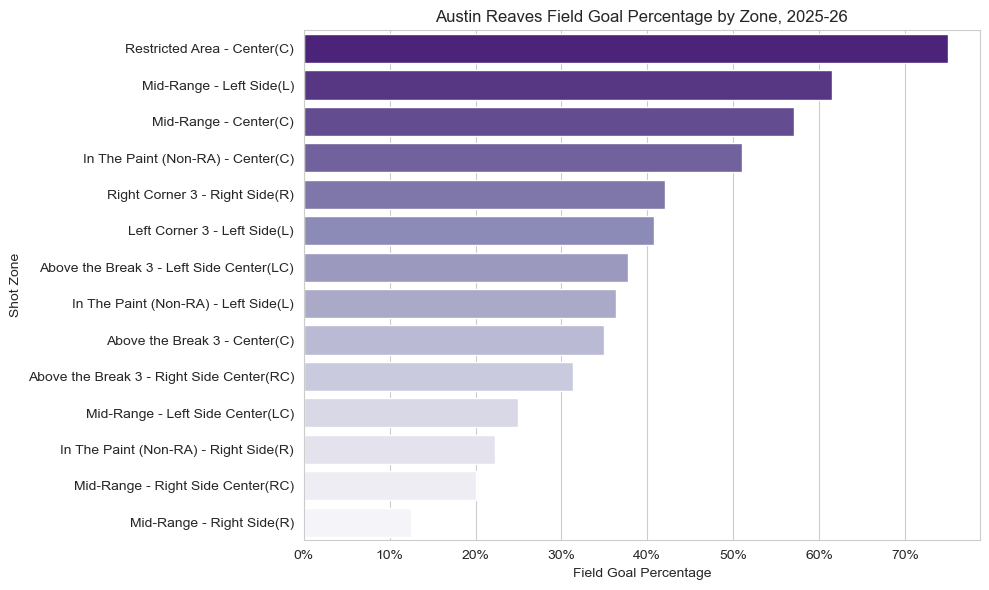

In [92]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=zone_summary_filtered.sort_values('fg_pct', ascending=False),
    x='fg_pct',
    y='shot_zone',
    hue='shot_zone',
    palette='Purples_r',
    legend=False
)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title('Austin Reaves Field Goal Percentage by Zone, 2025-26')
plt.xlabel('Field Goal Percentage')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

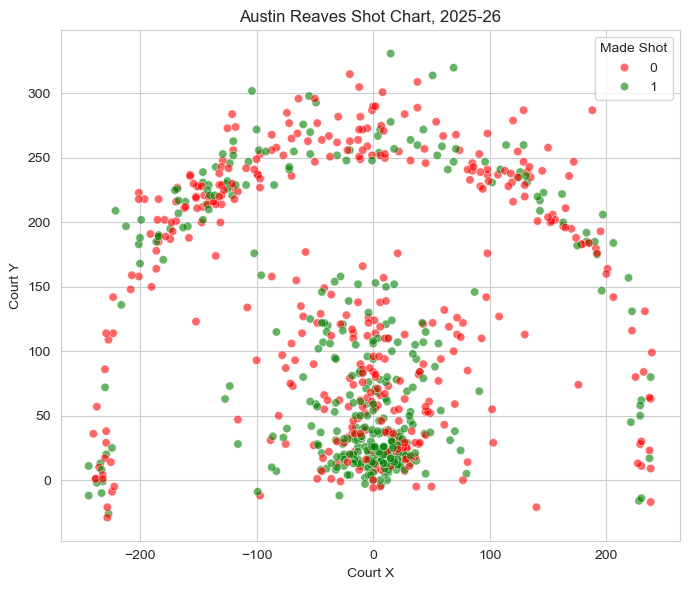

In [93]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=reaves_shots,
    x='LOC_X',
    y='LOC_Y',
    hue='made',
    palette={0: 'red', 1: 'green'},
    alpha=0.6
)

plt.title('Austin Reaves Shot Chart, 2025-26')
plt.xlabel('Court X')
plt.ylabel('Court Y')
plt.legend(title='Made Shot')
plt.tight_layout()
plt.show()

In [ ]:
## Shot Zone Efficiency

After reviewing Austin Reaves' points per shot by shot type, I analyzed his shot profile by court zone. 
This helps identify not only which shots are efficient, but also where those shots are coming from on the floor. 
I calculated attempts, makes, field goal percentage, total points, and points per shot for each shot zone.

The zone-level summary shows where Reaves generated the most value as a scorer. Zones with high points per shot represent efficient scoring areas, while high-attempt zones show where his shot diet is concentrated. Comparing volume and efficiency helps determine whether his shot selection is aligned with his most valuable areas.

In [ ]:
## Shot Zone Analysis

After analyzing Austin Reaves' points per shot by shot type, the next step is to examine where those shots come from on the court. This section groups his shots by court zone and compares shot volume, field goal percentage, and points per shot.

In [94]:
reaves_shots.head()

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,HTM,VTM,made,shot_value,actual_points,seconds_remaining,shot_zone,expected_make_prob,expected_points,points_above_expected
0,Shot Chart Detail,0022500002,14,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,10,39,...,LAL,GSW,1,2,2,639,Restricted Area - Center(C),0.662166,1.324332,0.675668
1,Shot Chart Detail,0022500002,67,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,6,12,...,LAL,GSW,0,2,0,372,Restricted Area - Center(C),0.714199,1.428399,-1.428399
2,Shot Chart Detail,0022500002,74,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,5,46,...,LAL,GSW,0,3,0,346,Above the Break 3 - Center(C),0.373017,1.119050,-1.119050
3,Shot Chart Detail,0022500002,164,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,0,37,...,LAL,GSW,1,2,2,37,Restricted Area - Center(C),0.697310,1.394620,0.605380
4,Shot Chart Detail,0022500002,182,1630559,Austin Reaves,1610612747,Los Angeles Lakers,1,0,0,...,LAL,GSW,0,3,0,0,Above the Break 3 - Left Side Center(LC),0.244303,0.732910,-0.732910


In [95]:
reaves_shots.columns

Index(['GRID_TYPE', 'GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME',
       'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING',
       'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE',
       'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE',
       'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE',
       'HTM', 'VTM', 'made', 'shot_value', 'actual_points',
       'seconds_remaining', 'shot_zone', 'expected_make_prob',
       'expected_points', 'points_above_expected'],
      dtype='object')

In [96]:
# Make sure made/missed is stored as 0/1
reaves_shots['made'] = reaves_shots['SHOT_MADE_FLAG'].astype(int)

# Assign shot value: 3 for threes, 2 for twos
reaves_shots['shot_value'] = reaves_shots['SHOT_TYPE'].apply(
    lambda x: 3 if '3PT' in x else 2
)

# Calculate actual points from each shot
reaves_shots['actual_points'] = reaves_shots['made'] * reaves_shots['shot_value']

# Create a readable shot zone label
reaves_shots['shot_zone'] = (
    reaves_shots['SHOT_ZONE_BASIC'].astype(str) + ' - ' +
    reaves_shots['SHOT_ZONE_AREA'].astype(str)
)

In [97]:
zone_summary = (
    reaves_shots
    .groupby('shot_zone')
    .agg(
        attempts=('made', 'count'),
        makes=('made', 'sum'),
        fg_pct=('made', 'mean'),
        points=('actual_points', 'sum'),
        points_per_shot=('actual_points', 'mean'),
        avg_distance=('SHOT_DISTANCE', 'mean')
    )
    .reset_index()
    .sort_values('attempts', ascending=False)
)

zone_summary

,shot_zone,attempts,makes,fg_pct,points,points_per_shot,avg_distance
3,In The Paint (Non-RA) - Center(C),190,97,0.510526,194,1.021053,7.626316
12,Restricted Area - Center(C),176,132,0.750000,264,1.500000,2.000000
1,Above the Break 3 - Left Side Center(LC),119,45,0.378151,135,1.134454,26.184874
2,Above the Break 3 - Right Side Center(RC),83,26,0.313253,78,0.939759,26.036145
0,Above the Break 3 - Center(C),80,28,0.350000,84,1.050000,26.787500
6,Left Corner 3 - Left Side(L),27,11,0.407407,33,1.222222,22.925926
13,Right Corner 3 - Right Side(R),19,8,0.421053,24,1.263158,23.105263
7,Mid-Range - Center(C),14,8,0.571429,16,1.142857,15.000000
9,Mid-Range - Left Side(L),13,8,0.615385,16,1.230769,10.692308
4,In The Paint (Non-RA) - Left Side(L),11,4,0.363636,8,0.727273,9.818182


In [98]:
zone_summary_display = zone_summary.copy()

zone_summary_display['fg_pct'] = zone_summary_display['fg_pct'].round(3)
zone_summary_display['points_per_shot'] = zone_summary_display['points_per_shot'].round(3)
zone_summary_display['avg_distance'] = zone_summary_display['avg_distance'].round(1)

zone_summary_display

,shot_zone,attempts,makes,fg_pct,points,points_per_shot,avg_distance
3,In The Paint (Non-RA) - Center(C),190,97,0.511,194,1.021,7.6
12,Restricted Area - Center(C),176,132,0.750,264,1.500,2.0
1,Above the Break 3 - Left Side Center(LC),119,45,0.378,135,1.134,26.2
2,Above the Break 3 - Right Side Center(RC),83,26,0.313,78,0.940,26.0
0,Above the Break 3 - Center(C),80,28,0.350,84,1.050,26.8
6,Left Corner 3 - Left Side(L),27,11,0.407,33,1.222,22.9
13,Right Corner 3 - Right Side(R),19,8,0.421,24,1.263,23.1
7,Mid-Range - Center(C),14,8,0.571,16,1.143,15.0
9,Mid-Range - Left Side(L),13,8,0.615,16,1.231,10.7
4,In The Paint (Non-RA) - Left Side(L),11,4,0.364,8,0.727,9.8


In [99]:
zone_summary_filtered = zone_summary[zone_summary['attempts'] >= 5].copy()

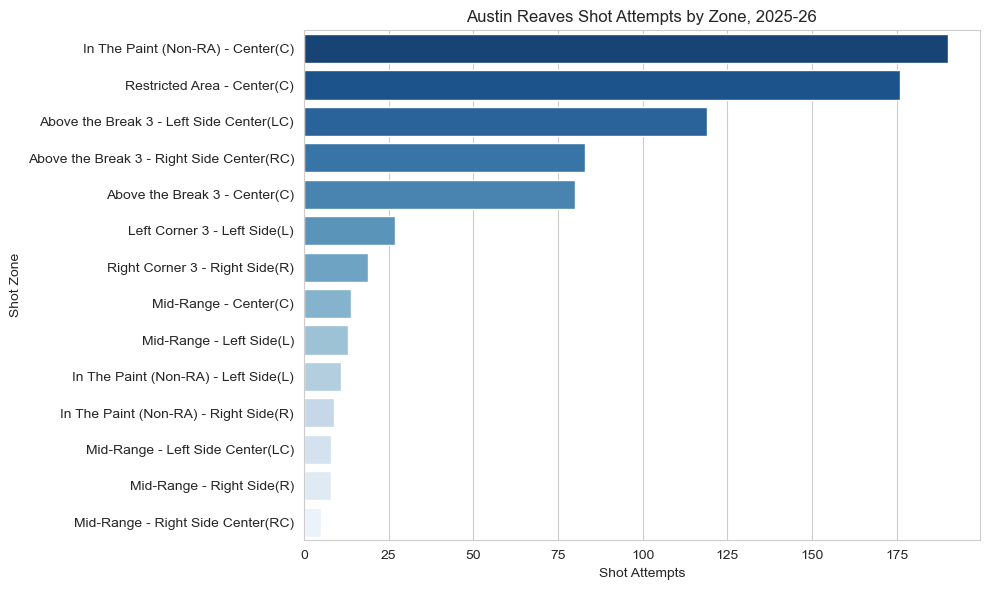

In [100]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_summary_filtered.sort_values('attempts', ascending=False),
    x='attempts',
    y='shot_zone',
    hue='shot_zone',
    palette='Blues_r',
    legend=False
)

plt.title('Austin Reaves Shot Attempts by Zone, 2025-26')
plt.xlabel('Shot Attempts')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

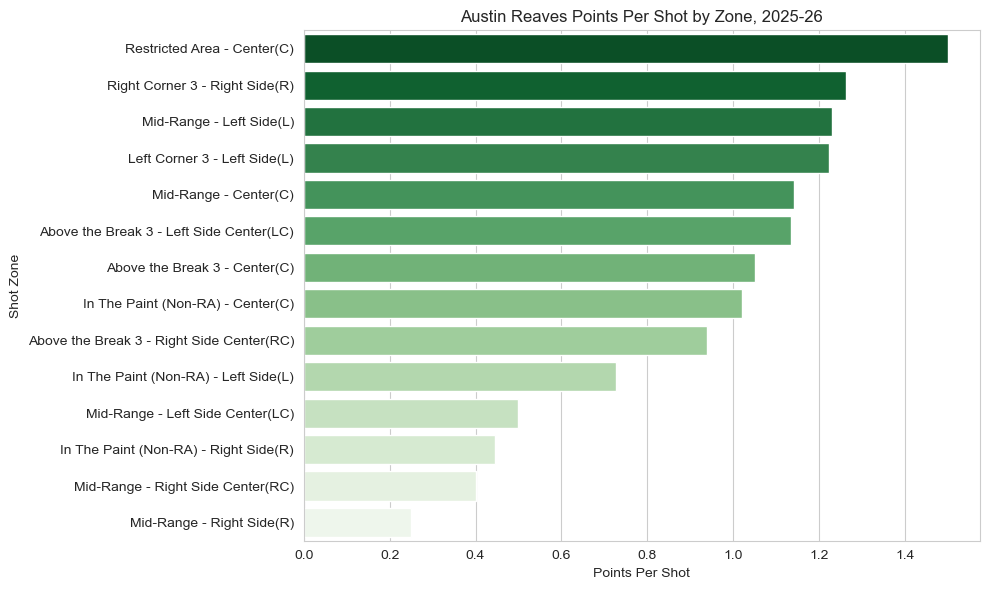

In [101]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_summary_filtered.sort_values('points_per_shot', ascending=False),
    x='points_per_shot',
    y='shot_zone',
    hue='shot_zone',
    palette='Greens_r',
    legend=False
)

plt.title('Austin Reaves Points Per Shot by Zone, 2025-26')
plt.xlabel('Points Per Shot')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

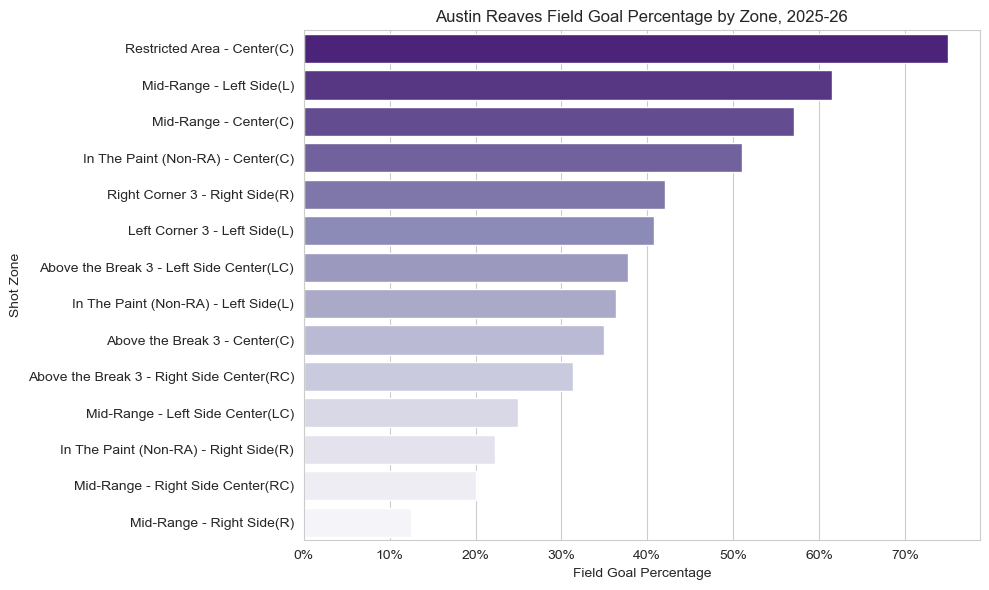

In [102]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=zone_summary_filtered.sort_values('fg_pct', ascending=False),
    x='fg_pct',
    y='shot_zone',
    hue='shot_zone',
    palette='Purples_r',
    legend=False
)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title('Austin Reaves Field Goal Percentage by Zone, 2025-26')
plt.xlabel('Field Goal Percentage')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

In [ ]:
#The zone analysis shows how Austin Reaves' efficiency changes depending on where he shoots from. Shot attempts by zone reveal his shot diet, while points per shot shows which areas generate the most scoring value. Field goal percentage adds context, but points per shot is more useful for comparing two-point and three-point areas because it accounts for the extra value of three-point shots.

In [103]:
zone_summary_filtered.sort_values('points_per_shot', ascending=False)[
    ['shot_zone', 'attempts', 'makes', 'fg_pct', 'points_per_shot', 'avg_distance']
]

,shot_zone,attempts,makes,fg_pct,points_per_shot,avg_distance
12,Restricted Area - Center(C),176,132,0.750000,1.500000,2.000000
13,Right Corner 3 - Right Side(R),19,8,0.421053,1.263158,23.105263
9,Mid-Range - Left Side(L),13,8,0.615385,1.230769,10.692308
6,Left Corner 3 - Left Side(L),27,11,0.407407,1.222222,22.925926
7,Mid-Range - Center(C),14,8,0.571429,1.142857,15.000000
1,Above the Break 3 - Left Side Center(LC),119,45,0.378151,1.134454,26.184874
0,Above the Break 3 - Center(C),80,28,0.350000,1.050000,26.787500
3,In The Paint (Non-RA) - Center(C),190,97,0.510526,1.021053,7.626316
2,Above the Break 3 - Right Side Center(RC),83,26,0.313253,0.939759,26.036145
4,In The Paint (Non-RA) - Left Side(L),11,4,0.363636,0.727273,9.818182


In [ ]:
## Shot Chart Visualization

To better understand Austin Reaves' 2025-26 shot profile, I plotted his shot attempts by court location. This helps show where his attempts are concentrated and whether certain areas of the floor stand out as makes or misses.

In [104]:
reaves_shots[['LOC_X', 'LOC_Y', 'made', 'SHOT_TYPE', 'shot_zone']].head()

,LOC_X,LOC_Y,made,SHOT_TYPE,shot_zone
0,-13,32,1,2PT Field Goal,Restricted Area - Center(C)
1,27,7,0,2PT Field Goal,Restricted Area - Center(C)
2,-38,267,0,3PT Field Goal,Above the Break 3 - Center(C)
3,4,17,1,2PT Field Goal,Restricted Area - Center(C)
4,-184,190,0,3PT Field Goal,Above the Break 3 - Left Side Center(LC)


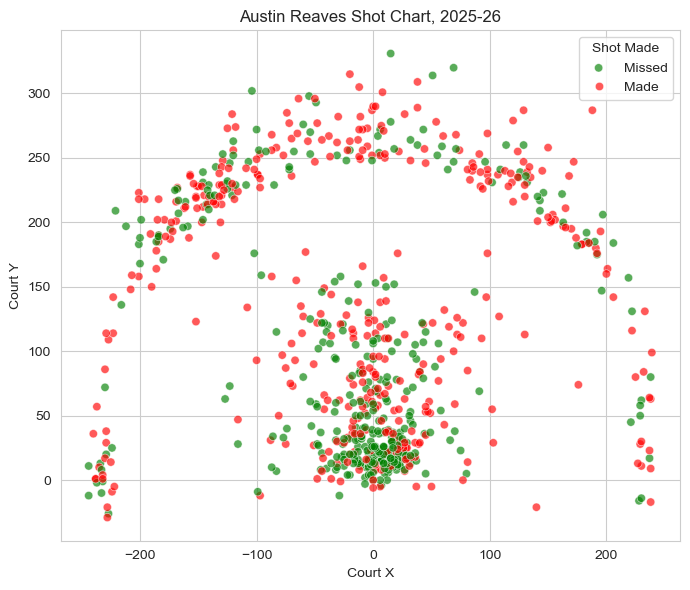

In [105]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=reaves_shots,
    x='LOC_X',
    y='LOC_Y',
    hue='made',
    palette={0: 'red', 1: 'green'},
    alpha=0.65
)

plt.title('Austin Reaves Shot Chart, 2025-26')
plt.xlabel('Court X')
plt.ylabel('Court Y')
plt.legend(title='Shot Made', labels=['Missed', 'Made'])
plt.tight_layout()
plt.show()

In [106]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc

def draw_half_court(ax=None, color='black', lw=1.5):
    if ax is None:
        ax = plt.gca()

    # Hoop
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # Backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # Paint
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)

    # Free throw circle
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color)
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color, linestyle='dashed')

    # Restricted area
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)

    # Three-point line
    corner_three_left = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_right = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)

    # Center court arc
    center_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color)

    court_elements = [
        hoop,
        backboard,
        outer_box,
        inner_box,
        top_free_throw,
        bottom_free_throw,
        restricted,
        corner_three_left,
        corner_three_right,
        three_arc,
        center_arc
    ]

    for element in court_elements:
        ax.add_patch(element)

    return ax

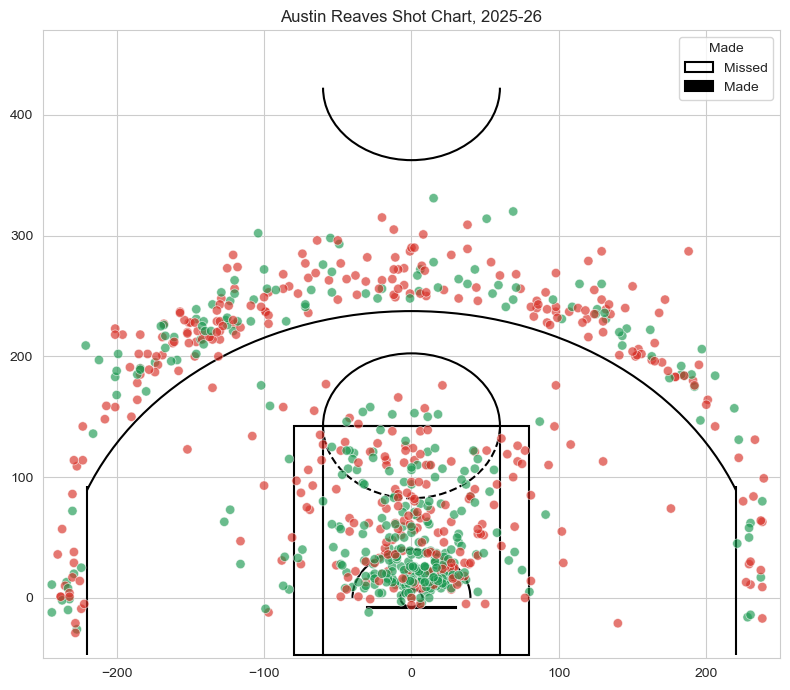

In [107]:
plt.figure(figsize=(8, 7))

ax = plt.gca()
draw_half_court(ax)

sns.scatterplot(
    data=reaves_shots,
    x='LOC_X',
    y='LOC_Y',
    hue='made',
    palette={0: '#d73027', 1: '#1a9850'},
    alpha=0.65,
    s=45,
    ax=ax
)

plt.xlim(-250, 250)
plt.ylim(-50, 470)

plt.title('Austin Reaves Shot Chart, 2025-26')
plt.xlabel('')
plt.ylabel('')
plt.legend(title='Made', labels=['Missed', 'Made'])
plt.tight_layout()
plt.show()

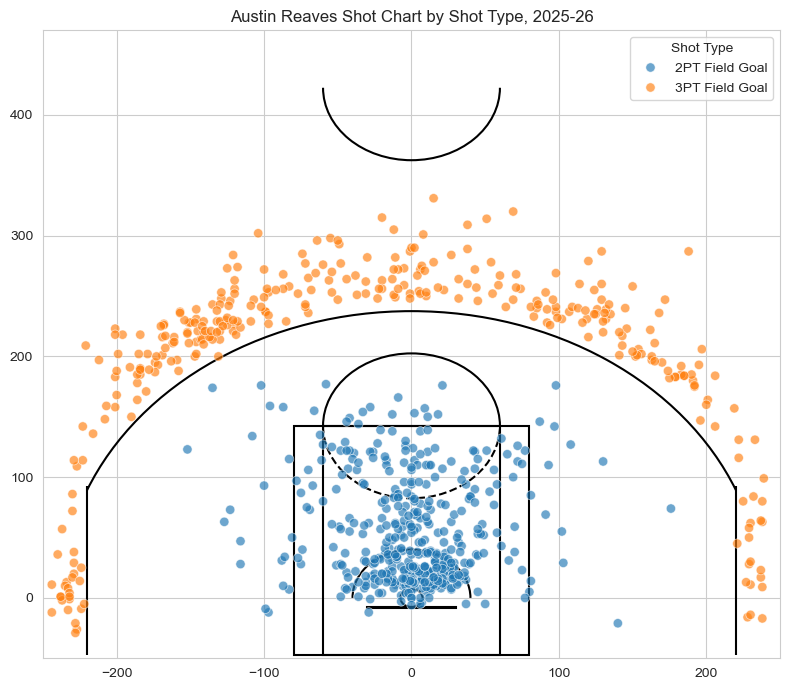

In [108]:
plt.figure(figsize=(8, 7))

ax = plt.gca()
draw_half_court(ax)

sns.scatterplot(
    data=reaves_shots,
    x='LOC_X',
    y='LOC_Y',
    hue='SHOT_TYPE',
    alpha=0.65,
    s=45,
    ax=ax
)

plt.xlim(-250, 250)
plt.ylim(-50, 470)

plt.title('Austin Reaves Shot Chart by Shot Type, 2025-26')
plt.xlabel('')
plt.ylabel('')
plt.legend(title='Shot Type')
plt.tight_layout()
plt.show()

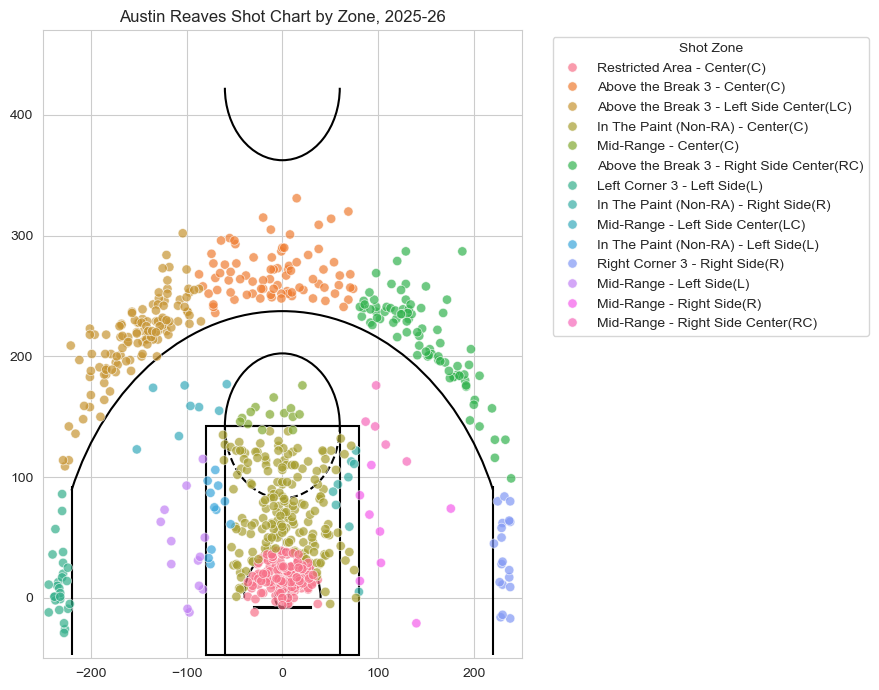

In [109]:
plt.figure(figsize=(9, 7))

ax = plt.gca()
draw_half_court(ax)

sns.scatterplot(
    data=reaves_shots,
    x='LOC_X',
    y='LOC_Y',
    hue='shot_zone',
    alpha=0.7,
    s=45,
    ax=ax
)

plt.xlim(-250, 250)
plt.ylim(-50, 470)

plt.title('Austin Reaves Shot Chart by Zone, 2025-26')
plt.xlabel('')
plt.ylabel('')
plt.legend(title='Shot Zone', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

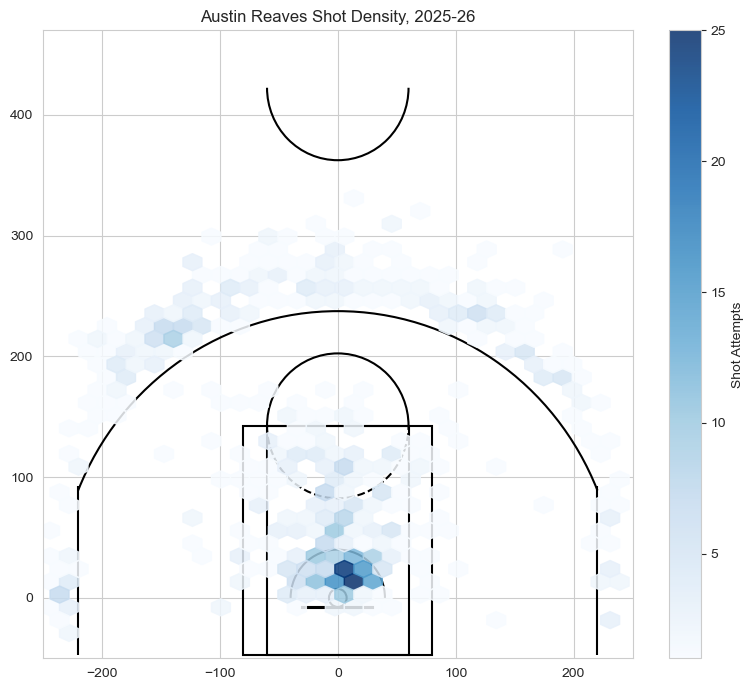

In [110]:
plt.figure(figsize=(8, 7))

ax = plt.gca()
draw_half_court(ax)

hb = plt.hexbin(
    reaves_shots['LOC_X'],
    reaves_shots['LOC_Y'],
    gridsize=30,
    cmap='Blues',
    mincnt=1,
    alpha=0.85
)

plt.colorbar(hb, label='Shot Attempts')

plt.xlim(-250, 250)
plt.ylim(-50, 470)

plt.title('Austin Reaves Shot Density, 2025-26')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
#The shot chart provides a visual view of Austin Reaves' shot distribution. While the zone charts summarize his efficiency numerically, the court map shows where his attempts are physically concentrated. 
#The density chart is especially useful for identifying high-volume areas, while the made/missed scatterplot gives a first look at location-based efficiency.

In [111]:
len(reaves_shots)

762

In [112]:
reaves_shots['made'].value_counts()

made
0    389
1    373
Name: count, dtype: int64

In [113]:
reaves_shots['SHOT_TYPE'].value_counts()

SHOT_TYPE
2PT Field Goal    434
3PT Field Goal    328
Name: count, dtype: int64

In [115]:
reaves_shots['expected_points'] = (
    reaves_shots['expected_make_prob'] * reaves_shots['shot_value']
)

In [ ]:
## Expected Shot Value Model

After analyzing Austin Reaves' shot profile by type, zone, and court location, I built a simple expected shot value model. The model estimates the probability that a shot will be made based on location, distance, shot type, zone, period, and time remaining. This allows actual shot value to be compared against expected shot value.

In [116]:
reaves_shots.columns

Index(['GRID_TYPE', 'GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME',
       'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING',
       'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE',
       'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE',
       'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE',
       'HTM', 'VTM', 'made', 'shot_value', 'actual_points',
       'seconds_remaining', 'shot_zone', 'expected_make_prob',
       'expected_points', 'points_above_expected'],
      dtype='object')

In [117]:
reaves_shots['made'] = reaves_shots['SHOT_MADE_FLAG'].astype(int)

reaves_shots['shot_value'] = reaves_shots['SHOT_TYPE'].apply(
    lambda x: 3 if '3PT' in x else 2
)

reaves_shots['actual_points'] = reaves_shots['made'] * reaves_shots['shot_value']

reaves_shots['seconds_remaining'] = (
    reaves_shots['MINUTES_REMAINING'] * 60 + reaves_shots['SECONDS_REMAINING']
)

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

In [119]:
features = [
    'SHOT_DISTANCE',
    'LOC_X',
    'LOC_Y',
    'SHOT_TYPE',
    'ACTION_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE',
    'PERIOD',
    'seconds_remaining'
]

target = 'made'

In [120]:
model_df = reaves_shots.dropna(subset=features + [target]).copy()

X = model_df[features]
y = model_df[target]

In [121]:
numeric_features = [
    'SHOT_DISTANCE',
    'LOC_X',
    'LOC_Y',
    'PERIOD',
    'seconds_remaining'
]

categorical_features = [
    'SHOT_TYPE',
    'ACTION_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE'
]

In [122]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

shot_quality_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [124]:
shot_quality_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SHOT_DISTANCE', 'LOC_X',
                                                   'LOC_Y', 'PERIOD',
                                                   'seconds_remaining']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SHOT_TYPE', 'ACTION_TYPE',
                                                   'SHOT_ZONE_BASIC',
                                                   'SHOT_ZONE_AREA',
                                                   'SHOT_ZONE_RANGE'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [125]:
test_probs = shot_quality_model.predict_proba(X_test)[:, 1]
test_preds = shot_quality_model.predict(X_test)

print("AUC:", round(roc_auc_score(y_test, test_probs), 3))
print("Accuracy:", round(accuracy_score(y_test, test_preds), 3))

AUC: 0.691
Accuracy: 0.649


In [126]:
model_df['expected_make_prob'] = shot_quality_model.predict_proba(
    model_df[features]
)[:, 1]

In [127]:
model_df['expected_points'] = (
    model_df['expected_make_prob'] * model_df['shot_value']
)

In [128]:
model_df['points_above_expected'] = (
    model_df['actual_points'] - model_df['expected_points']
)

In [129]:
model_df[
    [
        'SHOT_TYPE',
        'SHOT_DISTANCE',
        'made',
        'shot_value',
        'actual_points',
        'expected_make_prob',
        'expected_points',
        'points_above_expected'
    ]
].head()

,SHOT_TYPE,SHOT_DISTANCE,made,shot_value,actual_points,expected_make_prob,expected_points,points_above_expected
0,2PT Field Goal,3,1,2,2,0.662166,1.324332,0.675668
1,2PT Field Goal,2,0,2,0,0.714199,1.428399,-1.428399
2,3PT Field Goal,26,0,3,0,0.373017,1.119050,-1.119050
3,2PT Field Goal,1,1,2,2,0.697310,1.394620,0.605380
4,3PT Field Goal,26,0,3,0,0.244303,0.732910,-0.732910


In [130]:
shot_type_expected = (
    model_df
    .groupby('SHOT_TYPE')
    .agg(
        attempts=('made', 'count'),
        actual_points=('actual_points', 'sum'),
        expected_points=('expected_points', 'sum'),
        actual_pps=('actual_points', 'mean'),
        expected_pps=('expected_points', 'mean'),
        points_above_expected=('points_above_expected', 'sum')
    )
    .reset_index()
)

shot_type_expected['pps_difference'] = (
    shot_type_expected['actual_pps'] - shot_type_expected['expected_pps']
)

shot_type_expected

,SHOT_TYPE,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
0,2PT Field Goal,434,510,510.633360,1.175115,1.176575,-0.633360,-0.001459
1,3PT Field Goal,328,354,344.240149,1.079268,1.049513,9.759851,0.029756


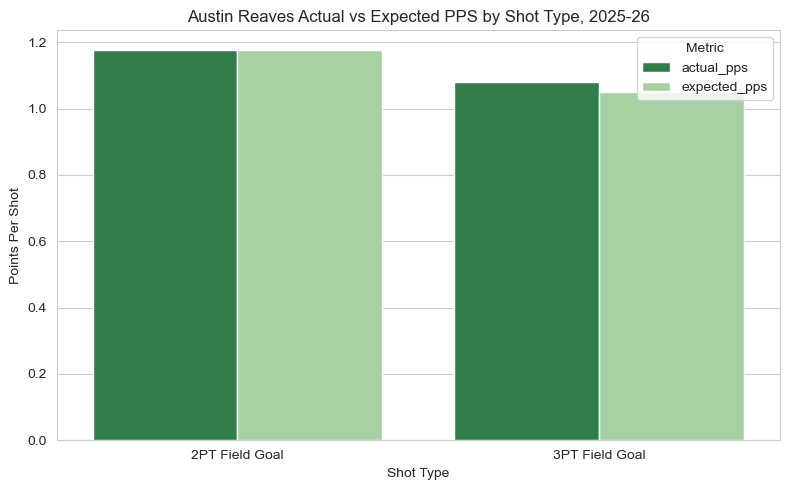

In [131]:
shot_type_plot = shot_type_expected.melt(
    id_vars='SHOT_TYPE',
    value_vars=['actual_pps', 'expected_pps'],
    var_name='Metric',
    value_name='Points Per Shot'
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=shot_type_plot,
    x='SHOT_TYPE',
    y='Points Per Shot',
    hue='Metric',
    palette=['#238b45', '#a1d99b']
)

plt.title('Austin Reaves Actual vs Expected PPS by Shot Type, 2025-26')
plt.xlabel('Shot Type')
plt.ylabel('Points Per Shot')
plt.tight_layout()
plt.show()

In [132]:
model_df['expected_points'] = (
    model_df['expected_make_prob'] * model_df['shot_value']
)

In [133]:
model_df['expected_make_prob'] = shot_quality_model.predict_proba(model_df[features])[:, 1]

In [134]:
reaves_shots.columns

Index(['GRID_TYPE', 'GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME',
       'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING',
       'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE',
       'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE',
       'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE',
       'HTM', 'VTM', 'made', 'shot_value', 'actual_points',
       'seconds_remaining', 'shot_zone', 'expected_make_prob',
       'expected_points', 'points_above_expected'],
      dtype='object')

In [135]:
reaves_shots['made'] = reaves_shots['SHOT_MADE_FLAG'].astype(int)

reaves_shots['shot_value'] = reaves_shots['SHOT_TYPE'].apply(
    lambda x: 3 if '3PT' in x else 2
)

reaves_shots['actual_points'] = reaves_shots['made'] * reaves_shots['shot_value']

reaves_shots['seconds_remaining'] = (
    reaves_shots['MINUTES_REMAINING'] * 60 + reaves_shots['SECONDS_REMAINING']
)

In [136]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

In [137]:
features = [
    'SHOT_DISTANCE',
    'LOC_X',
    'LOC_Y',
    'SHOT_TYPE',
    'ACTION_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE',
    'PERIOD',
    'seconds_remaining'
]

target = 'made'

In [138]:
model_df = reaves_shots.dropna(subset=features + [target]).copy()

X = model_df[features]
y = model_df[target]

In [139]:
numeric_features = [
    'SHOT_DISTANCE',
    'LOC_X',
    'LOC_Y',
    'PERIOD',
    'seconds_remaining'
]

categorical_features = [
    'SHOT_TYPE',
    'ACTION_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE'
]

In [140]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

shot_quality_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)

In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

shot_quality_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SHOT_DISTANCE', 'LOC_X',
                                                   'LOC_Y', 'PERIOD',
                                                   'seconds_remaining']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SHOT_TYPE', 'ACTION_TYPE',
                                                   'SHOT_ZONE_BASIC',
                                                   'SHOT_ZONE_AREA',
                                                   'SHOT_ZONE_RANGE'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [142]:
test_probs = shot_quality_model.predict_proba(X_test)[:, 1]
test_preds = shot_quality_model.predict(X_test)

print("AUC:", round(roc_auc_score(y_test, test_probs), 3))
print("Accuracy:", round(accuracy_score(y_test, test_preds), 3))

AUC: 0.691
Accuracy: 0.649


In [143]:
model_df['expected_make_prob'] = shot_quality_model.predict_proba(
    model_df[features]
)[:, 1]

In [144]:
model_df['expected_points'] = (
    model_df['expected_make_prob'] * model_df['shot_value']
)

In [145]:
model_df['points_above_expected'] = (
    model_df['actual_points'] - model_df['expected_points']
)

In [146]:
model_df[
    [
        'SHOT_TYPE',
        'ACTION_TYPE',
        'SHOT_DISTANCE',
        'made',
        'shot_value',
        'actual_points',
        'expected_make_prob',
        'expected_points',
        'points_above_expected'
    ]
].head()

,SHOT_TYPE,ACTION_TYPE,SHOT_DISTANCE,made,shot_value,actual_points,expected_make_prob,expected_points,points_above_expected
0,2PT Field Goal,Driving Finger Roll Layup Shot,3,1,2,2,0.662166,1.324332,0.675668
1,2PT Field Goal,Running Layup Shot,2,0,2,0,0.714199,1.428399,-1.428399
2,3PT Field Goal,Jump Shot,26,0,3,0,0.373017,1.119050,-1.119050
3,2PT Field Goal,Driving Finger Roll Layup Shot,1,1,2,2,0.697310,1.394620,0.605380
4,3PT Field Goal,Pullup Jump shot,26,0,3,0,0.244303,0.732910,-0.732910


In [147]:
shot_type_expected = (
    model_df
    .groupby('SHOT_TYPE')
    .agg(
        attempts=('made', 'count'),
        actual_points=('actual_points', 'sum'),
        expected_points=('expected_points', 'sum'),
        actual_pps=('actual_points', 'mean'),
        expected_pps=('expected_points', 'mean'),
        points_above_expected=('points_above_expected', 'sum')
    )
    .reset_index()
)

shot_type_expected['pps_difference'] = (
    shot_type_expected['actual_pps'] - shot_type_expected['expected_pps']
)

shot_type_expected

,SHOT_TYPE,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
0,2PT Field Goal,434,510,510.633360,1.175115,1.176575,-0.633360,-0.001459
1,3PT Field Goal,328,354,344.240149,1.079268,1.049513,9.759851,0.029756


In [148]:
zone_expected = (
    model_df
    .groupby('shot_zone')
    .agg(
        attempts=('made', 'count'),
        actual_points=('actual_points', 'sum'),
        expected_points=('expected_points', 'sum'),
        actual_pps=('actual_points', 'mean'),
        expected_pps=('expected_points', 'mean'),
        points_above_expected=('points_above_expected', 'sum')
    )
    .reset_index()
)

zone_expected['pps_difference'] = (
    zone_expected['actual_pps'] - zone_expected['expected_pps']
)

zone_expected.sort_values('points_above_expected', ascending=False)

,shot_zone,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
6,Left Corner 3 - Left Side(L),27,33,23.502761,1.222222,0.870473,9.497239,0.351750
1,Above the Break 3 - Left Side Center(LC),119,135,126.479091,1.134454,1.062850,8.520909,0.071604
12,Restricted Area - Center(C),176,264,257.534031,1.500000,1.463262,6.465969,0.036738
9,Mid-Range - Left Side(L),13,16,13.431379,1.230769,1.033183,2.568621,0.197586
7,Mid-Range - Center(C),14,16,13.817230,1.142857,0.986945,2.182770,0.155912
8,Mid-Range - Left Side Center(LC),8,4,4.724932,0.500000,0.590616,-0.724932,-0.090616
10,Mid-Range - Right Side Center(RC),5,2,2.826591,0.400000,0.565318,-0.826591,-0.165318
13,Right Corner 3 - Right Side(R),19,24,24.833085,1.263158,1.307004,-0.833085,-0.043847
5,In The Paint (Non-RA) - Right Side(R),9,4,5.183897,0.444444,0.575989,-1.183897,-0.131544
4,In The Paint (Non-RA) - Left Side(L),11,8,10.239284,0.727273,0.930844,-2.239284,-0.203571


In [149]:
model_df['shot_zone'] = (
    model_df['SHOT_ZONE_BASIC'].astype(str) + ' - ' +
    model_df['SHOT_ZONE_AREA'].astype(str)
)

In [150]:
from sklearn.model_selection import train_test_split

In [151]:
model_df['points_above_expected'] = model_df['actual_points'] - model_df['expected_points']

In [ ]:
## Expected Shot Value Model

To evaluate shot quality, I built a simple logistic regression model that estimates the probability of each Austin Reaves shot being made based on shot distance, location, shot type, shot zone, period, and time remaining. The predicted make probability is then converted into expected points.

In [152]:
# Make sure made/missed is 0/1
reaves_shots['made'] = reaves_shots['SHOT_MADE_FLAG'].astype(int)

# Assign shot value
reaves_shots['shot_value'] = reaves_shots['SHOT_TYPE'].apply(
    lambda x: 3 if '3PT' in x else 2
)

# Actual points scored on each shot
reaves_shots['actual_points'] = reaves_shots['made'] * reaves_shots['shot_value']

# Time remaining in period
reaves_shots['seconds_remaining'] = (
    reaves_shots['MINUTES_REMAINING'] * 60 + reaves_shots['SECONDS_REMAINING']
)

# Zone label, useful later
reaves_shots['shot_zone'] = (
    reaves_shots['SHOT_ZONE_BASIC'].astype(str) + ' - ' +
    reaves_shots['SHOT_ZONE_AREA'].astype(str)
)

In [153]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

In [154]:
features = [
    'SHOT_DISTANCE',
    'LOC_X',
    'LOC_Y',
    'SHOT_TYPE',
    'ACTION_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE',
    'PERIOD',
    'seconds_remaining'
]

target = 'made'

In [155]:
model_df = reaves_shots.dropna(subset=features + [target]).copy()

X = model_df[features]
y = model_df[target]

In [156]:
numeric_features = [
    'SHOT_DISTANCE',
    'LOC_X',
    'LOC_Y',
    'PERIOD',
    'seconds_remaining'
]

categorical_features = [
    'SHOT_TYPE',
    'ACTION_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE'
]

In [157]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

shot_quality_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)

In [158]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

shot_quality_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SHOT_DISTANCE', 'LOC_X',
                                                   'LOC_Y', 'PERIOD',
                                                   'seconds_remaining']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SHOT_TYPE', 'ACTION_TYPE',
                                                   'SHOT_ZONE_BASIC',
                                                   'SHOT_ZONE_AREA',
                                                   'SHOT_ZONE_RANGE'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [159]:
test_probs = shot_quality_model.predict_proba(X_test)[:, 1]
test_preds = shot_quality_model.predict(X_test)

print("AUC:", round(roc_auc_score(y_test, test_probs), 3))
print("Accuracy:", round(accuracy_score(y_test, test_preds), 3))

AUC: 0.691
Accuracy: 0.649


In [160]:
model_df['expected_make_prob'] = shot_quality_model.predict_proba(
    model_df[features]
)[:, 1]

In [161]:
model_df['expected_points'] = (
    model_df['expected_make_prob'] * model_df['shot_value']
)

In [162]:
model_df['points_above_expected'] = (
    model_df['actual_points'] - model_df['expected_points']
)

In [163]:
model_df[
    [
        'SHOT_TYPE',
        'ACTION_TYPE',
        'SHOT_DISTANCE',
        'made',
        'shot_value',
        'actual_points',
        'expected_make_prob',
        'expected_points',
        'points_above_expected'
    ]
].head()

,SHOT_TYPE,ACTION_TYPE,SHOT_DISTANCE,made,shot_value,actual_points,expected_make_prob,expected_points,points_above_expected
0,2PT Field Goal,Driving Finger Roll Layup Shot,3,1,2,2,0.662166,1.324332,0.675668
1,2PT Field Goal,Running Layup Shot,2,0,2,0,0.714199,1.428399,-1.428399
2,3PT Field Goal,Jump Shot,26,0,3,0,0.373017,1.119050,-1.119050
3,2PT Field Goal,Driving Finger Roll Layup Shot,1,1,2,2,0.697310,1.394620,0.605380
4,3PT Field Goal,Pullup Jump shot,26,0,3,0,0.244303,0.732910,-0.732910


In [164]:
shot_type_expected = (
    model_df
    .groupby('SHOT_TYPE')
    .agg(
        attempts=('made', 'count'),
        actual_points=('actual_points', 'sum'),
        expected_points=('expected_points', 'sum'),
        actual_pps=('actual_points', 'mean'),
        expected_pps=('expected_points', 'mean'),
        points_above_expected=('points_above_expected', 'sum')
    )
    .reset_index()
)

shot_type_expected['pps_difference'] = (
    shot_type_expected['actual_pps'] - shot_type_expected['expected_pps']
)

shot_type_expected

,SHOT_TYPE,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
0,2PT Field Goal,434,510,510.633360,1.175115,1.176575,-0.633360,-0.001459
1,3PT Field Goal,328,354,344.240149,1.079268,1.049513,9.759851,0.029756


In [165]:
zone_expected = (
    model_df
    .groupby('shot_zone')
    .agg(
        attempts=('made', 'count'),
        actual_points=('actual_points', 'sum'),
        expected_points=('expected_points', 'sum'),
        actual_pps=('actual_points', 'mean'),
        expected_pps=('expected_points', 'mean'),
        points_above_expected=('points_above_expected', 'sum')
    )
    .reset_index()
)

zone_expected['pps_difference'] = (
    zone_expected['actual_pps'] - zone_expected['expected_pps']
)

zone_expected.sort_values('points_above_expected', ascending=False)

,shot_zone,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
6,Left Corner 3 - Left Side(L),27,33,23.502761,1.222222,0.870473,9.497239,0.351750
1,Above the Break 3 - Left Side Center(LC),119,135,126.479091,1.134454,1.062850,8.520909,0.071604
12,Restricted Area - Center(C),176,264,257.534031,1.500000,1.463262,6.465969,0.036738
9,Mid-Range - Left Side(L),13,16,13.431379,1.230769,1.033183,2.568621,0.197586
7,Mid-Range - Center(C),14,16,13.817230,1.142857,0.986945,2.182770,0.155912
8,Mid-Range - Left Side Center(LC),8,4,4.724932,0.500000,0.590616,-0.724932,-0.090616
10,Mid-Range - Right Side Center(RC),5,2,2.826591,0.400000,0.565318,-0.826591,-0.165318
13,Right Corner 3 - Right Side(R),19,24,24.833085,1.263158,1.307004,-0.833085,-0.043847
5,In The Paint (Non-RA) - Right Side(R),9,4,5.183897,0.444444,0.575989,-1.183897,-0.131544
4,In The Paint (Non-RA) - Left Side(L),11,8,10.239284,0.727273,0.930844,-2.239284,-0.203571


In [ ]:
## Actual vs Expected Shot Value

After estimating expected make probability for each shot, I compared Austin Reaves' actual scoring output to his expected scoring output. This shows where he added value relative to shot quality and where his results fell below expectation.

In [166]:
shot_type_expected = (
    model_df
    .groupby('SHOT_TYPE')
    .agg(
        attempts=('made', 'count'),
        actual_points=('actual_points', 'sum'),
        expected_points=('expected_points', 'sum'),
        actual_pps=('actual_points', 'mean'),
        expected_pps=('expected_points', 'mean'),
        points_above_expected=('points_above_expected', 'sum')
    )
    .reset_index()
)

shot_type_expected['pps_difference'] = (
    shot_type_expected['actual_pps'] - shot_type_expected['expected_pps']
)

shot_type_expected = shot_type_expected.sort_values(
    'points_above_expected',
    ascending=False
)

shot_type_expected

,SHOT_TYPE,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
1,3PT Field Goal,328,354,344.240149,1.079268,1.049513,9.759851,0.029756
0,2PT Field Goal,434,510,510.633360,1.175115,1.176575,-0.633360,-0.001459


In [167]:
shot_type_expected_display = shot_type_expected.copy()

cols = [
    'actual_points',
    'expected_points',
    'actual_pps',
    'expected_pps',
    'points_above_expected',
    'pps_difference'
]

shot_type_expected_display[cols] = shot_type_expected_display[cols].round(3)

shot_type_expected_display

,SHOT_TYPE,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
1,3PT Field Goal,328,354,344.240,1.079,1.050,9.760,0.030
0,2PT Field Goal,434,510,510.633,1.175,1.177,-0.633,-0.001


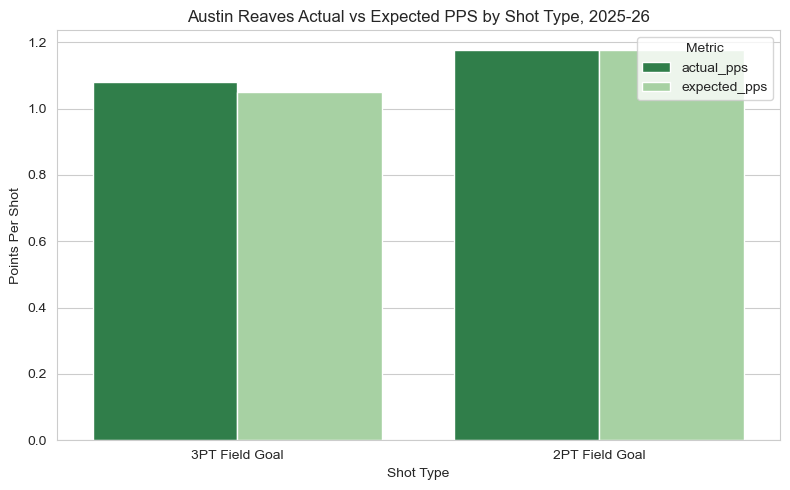

In [168]:
shot_type_plot = shot_type_expected.melt(
    id_vars='SHOT_TYPE',
    value_vars=['actual_pps', 'expected_pps'],
    var_name='Metric',
    value_name='Points Per Shot'
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=shot_type_plot,
    x='SHOT_TYPE',
    y='Points Per Shot',
    hue='Metric',
    palette=['#238b45', '#a1d99b']
)

plt.title('Austin Reaves Actual vs Expected PPS by Shot Type, 2025-26')
plt.xlabel('Shot Type')
plt.ylabel('Points Per Shot')
plt.tight_layout()
plt.show()

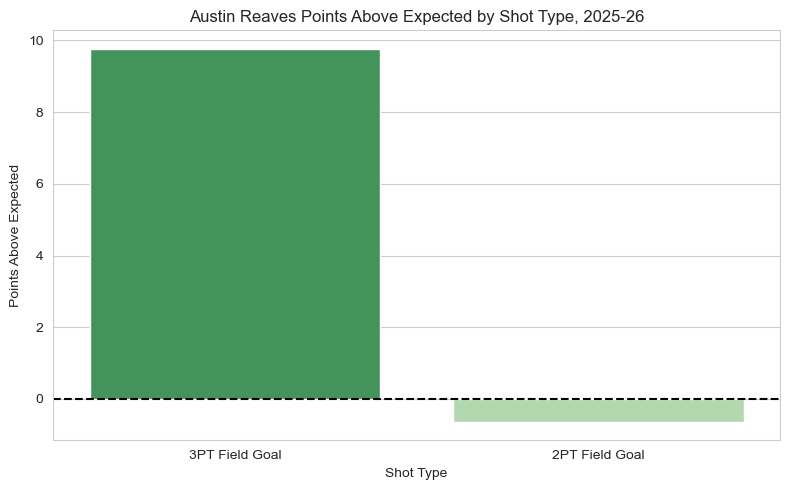

In [169]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=shot_type_expected.sort_values('points_above_expected', ascending=False),
    x='SHOT_TYPE',
    y='points_above_expected',
    hue='SHOT_TYPE',
    palette='Greens_r',
    legend=False
)

plt.axhline(0, color='black', linestyle='--')

plt.title('Austin Reaves Points Above Expected by Shot Type, 2025-26')
plt.xlabel('Shot Type')
plt.ylabel('Points Above Expected')
plt.tight_layout()
plt.show()

In [170]:
model_df['shot_zone'] = (
    model_df['SHOT_ZONE_BASIC'].astype(str) + ' - ' +
    model_df['SHOT_ZONE_AREA'].astype(str)
)

In [171]:
zone_expected = (
    model_df
    .groupby('shot_zone')
    .agg(
        attempts=('made', 'count'),
        actual_points=('actual_points', 'sum'),
        expected_points=('expected_points', 'sum'),
        actual_pps=('actual_points', 'mean'),
        expected_pps=('expected_points', 'mean'),
        points_above_expected=('points_above_expected', 'sum')
    )
    .reset_index()
)

zone_expected['pps_difference'] = (
    zone_expected['actual_pps'] - zone_expected['expected_pps']
)

zone_expected = zone_expected.sort_values(
    'points_above_expected',
    ascending=False
)

zone_expected

,shot_zone,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
6,Left Corner 3 - Left Side(L),27,33,23.502761,1.222222,0.870473,9.497239,0.351750
1,Above the Break 3 - Left Side Center(LC),119,135,126.479091,1.134454,1.062850,8.520909,0.071604
12,Restricted Area - Center(C),176,264,257.534031,1.500000,1.463262,6.465969,0.036738
9,Mid-Range - Left Side(L),13,16,13.431379,1.230769,1.033183,2.568621,0.197586
7,Mid-Range - Center(C),14,16,13.817230,1.142857,0.986945,2.182770,0.155912
8,Mid-Range - Left Side Center(LC),8,4,4.724932,0.500000,0.590616,-0.724932,-0.090616
10,Mid-Range - Right Side Center(RC),5,2,2.826591,0.400000,0.565318,-0.826591,-0.165318
13,Right Corner 3 - Right Side(R),19,24,24.833085,1.263158,1.307004,-0.833085,-0.043847
5,In The Paint (Non-RA) - Right Side(R),9,4,5.183897,0.444444,0.575989,-1.183897,-0.131544
4,In The Paint (Non-RA) - Left Side(L),11,8,10.239284,0.727273,0.930844,-2.239284,-0.203571


In [172]:
zone_expected_filtered = zone_expected[zone_expected['attempts'] >= 5].copy()

In [173]:
zone_expected_display = zone_expected_filtered.copy()

cols = [
    'actual_points',
    'expected_points',
    'actual_pps',
    'expected_pps',
    'points_above_expected',
    'pps_difference'
]

zone_expected_display[cols] = zone_expected_display[cols].round(3)

zone_expected_display.sort_values('points_above_expected', ascending=False)

,shot_zone,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
6,Left Corner 3 - Left Side(L),27,33,23.503,1.222,0.870,9.497,0.352
1,Above the Break 3 - Left Side Center(LC),119,135,126.479,1.134,1.063,8.521,0.072
12,Restricted Area - Center(C),176,264,257.534,1.500,1.463,6.466,0.037
9,Mid-Range - Left Side(L),13,16,13.431,1.231,1.033,2.569,0.198
7,Mid-Range - Center(C),14,16,13.817,1.143,0.987,2.183,0.156
8,Mid-Range - Left Side Center(LC),8,4,4.725,0.500,0.591,-0.725,-0.091
10,Mid-Range - Right Side Center(RC),5,2,2.827,0.400,0.565,-0.827,-0.165
13,Right Corner 3 - Right Side(R),19,24,24.833,1.263,1.307,-0.833,-0.044
5,In The Paint (Non-RA) - Right Side(R),9,4,5.184,0.444,0.576,-1.184,-0.132
4,In The Paint (Non-RA) - Left Side(L),11,8,10.239,0.727,0.931,-2.239,-0.204


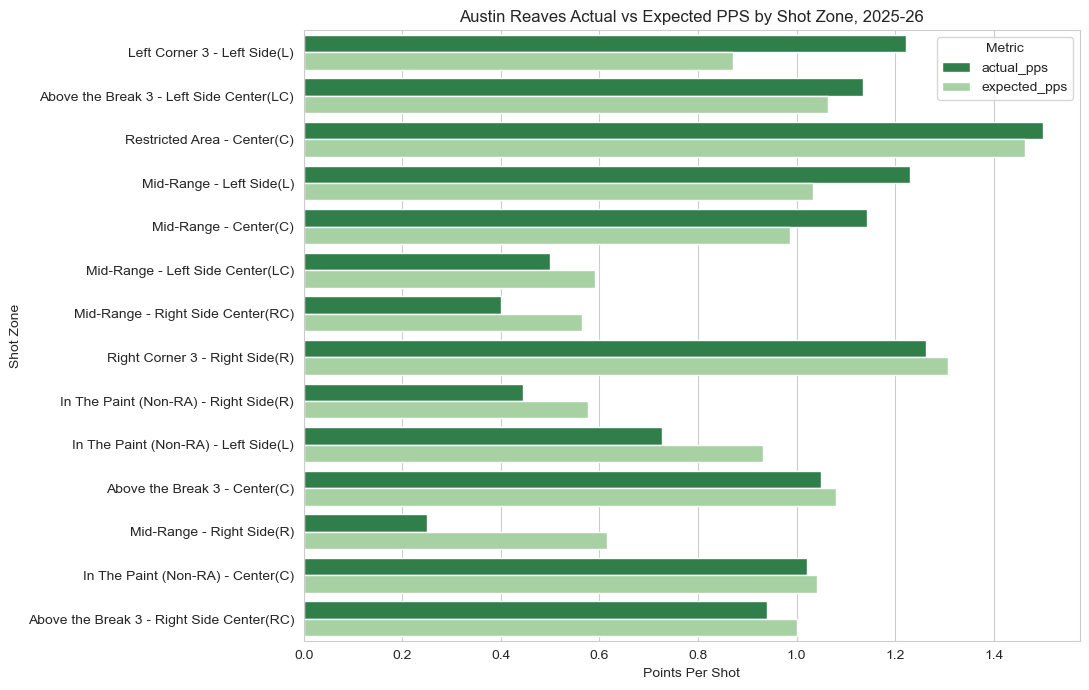

In [174]:
zone_plot = zone_expected_filtered.melt(
    id_vars='shot_zone',
    value_vars=['actual_pps', 'expected_pps'],
    var_name='Metric',
    value_name='Points Per Shot'
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=zone_plot,
    x='Points Per Shot',
    y='shot_zone',
    hue='Metric',
    palette=['#238b45', '#a1d99b']
)

plt.title('Austin Reaves Actual vs Expected PPS by Shot Zone, 2025-26')
plt.xlabel('Points Per Shot')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

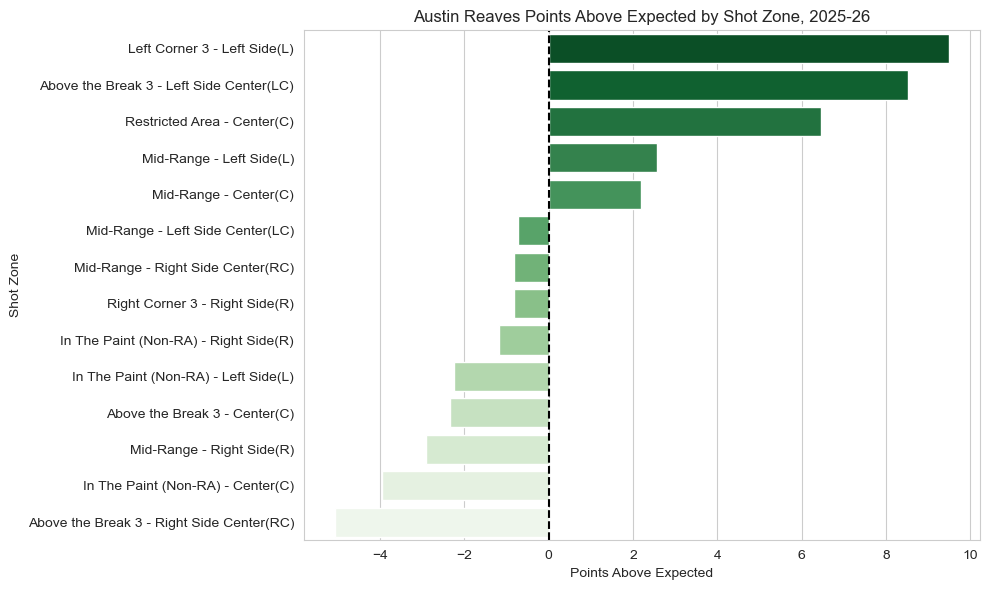

In [175]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=zone_expected_filtered.sort_values('points_above_expected', ascending=False),
    x='points_above_expected',
    y='shot_zone',
    hue='shot_zone',
    palette='Greens_r',
    legend=False
)

plt.axvline(0, color='black', linestyle='--')

plt.title('Austin Reaves Points Above Expected by Shot Zone, 2025-26')
plt.xlabel('Points Above Expected')
plt.ylabel('Shot Zone')
plt.tight_layout()
plt.show()

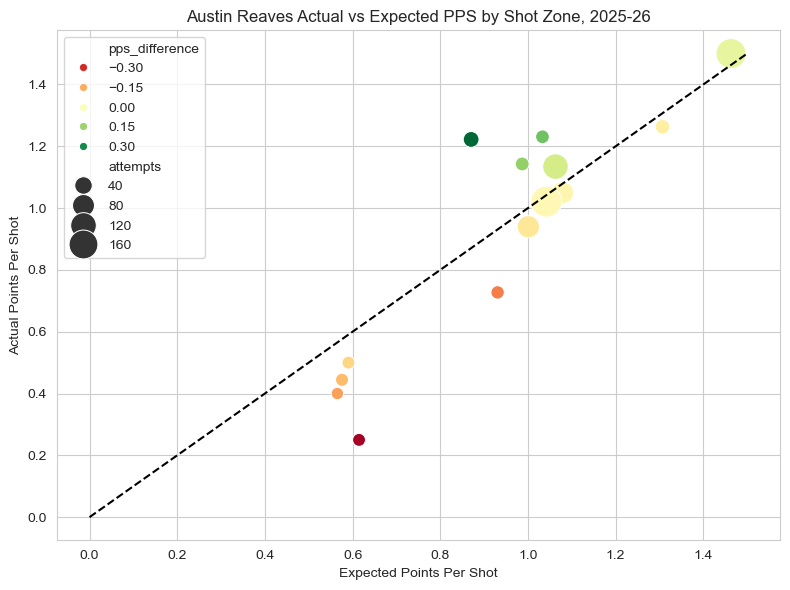

In [176]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=zone_expected_filtered,
    x='expected_pps',
    y='actual_pps',
    size='attempts',
    hue='pps_difference',
    palette='RdYlGn',
    sizes=(80, 500)
)

max_val = max(
    zone_expected_filtered['expected_pps'].max(),
    zone_expected_filtered['actual_pps'].max()
)

plt.plot([0, max_val], [0, max_val], color='black', linestyle='--')

plt.title('Austin Reaves Actual vs Expected PPS by Shot Zone, 2025-26')
plt.xlabel('Expected Points Per Shot')
plt.ylabel('Actual Points Per Shot')
plt.tight_layout()
plt.show()

In [178]:
zone_expected_filtered.sort_values(
    'points_above_expected',
    ascending=False
)[
    [
        'shot_zone',
        'attempts',
        'actual_pps',
        'expected_pps',
        'pps_difference',
        'points_above_expected'
    ]
].head(10)

,shot_zone,attempts,actual_pps,expected_pps,pps_difference,points_above_expected
6,Left Corner 3 - Left Side(L),27,1.222222,0.870473,0.351750,9.497239
1,Above the Break 3 - Left Side Center(LC),119,1.134454,1.062850,0.071604,8.520909
12,Restricted Area - Center(C),176,1.500000,1.463262,0.036738,6.465969
9,Mid-Range - Left Side(L),13,1.230769,1.033183,0.197586,2.568621
7,Mid-Range - Center(C),14,1.142857,0.986945,0.155912,2.182770
8,Mid-Range - Left Side Center(LC),8,0.500000,0.590616,-0.090616,-0.724932
10,Mid-Range - Right Side Center(RC),5,0.400000,0.565318,-0.165318,-0.826591
13,Right Corner 3 - Right Side(R),19,1.263158,1.307004,-0.043847,-0.833085
5,In The Paint (Non-RA) - Right Side(R),9,0.444444,0.575989,-0.131544,-1.183897
4,In The Paint (Non-RA) - Left Side(L),11,0.727273,0.930844,-0.203571,-2.239284


In [179]:
zone_expected_filtered.sort_values(
    'points_above_expected',
    ascending=True
)[
    [
        'shot_zone',
        'attempts',
        'actual_pps',
        'expected_pps',
        'pps_difference',
        'points_above_expected'
    ]
].head(10)

,shot_zone,attempts,actual_pps,expected_pps,pps_difference,points_above_expected
2,Above the Break 3 - Right Side Center(RC),83,0.939759,1.000965,-0.061206,-5.080083
3,In The Paint (Non-RA) - Center(C),190,1.021053,1.041883,-0.020830,-3.957723
11,Mid-Range - Right Side(R),8,0.250000,0.614786,-0.364786,-2.918291
0,Above the Break 3 - Center(C),80,1.050000,1.079314,-0.029314,-2.345128
4,In The Paint (Non-RA) - Left Side(L),11,0.727273,0.930844,-0.203571,-2.239284
5,In The Paint (Non-RA) - Right Side(R),9,0.444444,0.575989,-0.131544,-1.183897
13,Right Corner 3 - Right Side(R),19,1.263158,1.307004,-0.043847,-0.833085
10,Mid-Range - Right Side Center(RC),5,0.400000,0.565318,-0.165318,-0.826591
8,Mid-Range - Left Side Center(LC),8,0.500000,0.590616,-0.090616,-0.724932
7,Mid-Range - Center(C),14,1.142857,0.986945,0.155912,2.182770


In [180]:
zone_expected_filtered.sort_values(
    'pps_difference',
    ascending=False
)[
    [
        'shot_zone',
        'attempts',
        'actual_pps',
        'expected_pps',
        'pps_difference',
        'points_above_expected'
    ]
].head(10)

,shot_zone,attempts,actual_pps,expected_pps,pps_difference,points_above_expected
6,Left Corner 3 - Left Side(L),27,1.222222,0.870473,0.351750,9.497239
9,Mid-Range - Left Side(L),13,1.230769,1.033183,0.197586,2.568621
7,Mid-Range - Center(C),14,1.142857,0.986945,0.155912,2.182770
1,Above the Break 3 - Left Side Center(LC),119,1.134454,1.062850,0.071604,8.520909
12,Restricted Area - Center(C),176,1.500000,1.463262,0.036738,6.465969
3,In The Paint (Non-RA) - Center(C),190,1.021053,1.041883,-0.020830,-3.957723
0,Above the Break 3 - Center(C),80,1.050000,1.079314,-0.029314,-2.345128
13,Right Corner 3 - Right Side(R),19,1.263158,1.307004,-0.043847,-0.833085
2,Above the Break 3 - Right Side Center(RC),83,0.939759,1.000965,-0.061206,-5.080083
8,Mid-Range - Left Side Center(LC),8,0.500000,0.590616,-0.090616,-0.724932


In [ ]:
#The actual vs expected comparison adds context to Reaves' scoring efficiency. Instead of only looking at raw field goal percentage or points per shot, this section compares his production to the estimated value of his shot attempts. Positive points above expected indicates that Reaves generated more value than the model predicted, while negative values indicate lower-than-expected results.

This helps separate shot-making from shot selection. A zone can have high expected value because the shots are generally efficient, while another zone may stand out because Reaves personally outperformed expectation there.

In [181]:
shot_type_expected_display

,SHOT_TYPE,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
1,3PT Field Goal,328,354,344.240,1.079,1.050,9.760,0.030
0,2PT Field Goal,434,510,510.633,1.175,1.177,-0.633,-0.001


In [182]:
zone_expected_display.sort_values('points_above_expected', ascending=False).head()

,shot_zone,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
6,Left Corner 3 - Left Side(L),27,33,23.503,1.222,0.870,9.497,0.352
1,Above the Break 3 - Left Side Center(LC),119,135,126.479,1.134,1.063,8.521,0.072
12,Restricted Area - Center(C),176,264,257.534,1.500,1.463,6.466,0.037
9,Mid-Range - Left Side(L),13,16,13.431,1.231,1.033,2.569,0.198
7,Mid-Range - Center(C),14,16,13.817,1.143,0.987,2.183,0.156


In [ ]:
#Your results are actually pretty clean.

At the shot type level:

3PT Field Goals: 328 attempts 1.079 actual PPS 1.050 expected PPS +9.760 points above expected

2PT Field Goals: 434 attempts 1.175 actual PPS 1.177 expected PPS -0.633 points above expected

Interpretation:

Reaves slightly outperformed expectation on threes and was almost exactly at expectation on twos.

That means his biggest shot-making value, relative to expectation, came from three-point shooting. His two-point shots were still valuable overall, especially because 1.175 PPS is strong, but the model expected him to be around that level based on the quality/location of those looks.

So the clean takeaway is:

Reaves’ three-point shooting added value above expectation, while his two-point scoring was efficient but mostly in line with expected shot quality.

At the zone level, your top zones are:

Left Corner 3 - Left Side 27 attempts 1.222 actual PPS 0.870 expected PPS +9.497 points above expected
This is his biggest positive zone by total points above expected.

Interpretation: He strongly outperformed expectation from the left corner three area. However, this is only 27 attempts, so it is a meaningful but somewhat small sample. You can say it was his most efficient overperformance zone, but avoid overclaiming that it is definitely sustainable.

Above the Break 3 - Left Side Center 119 attempts 1.134 actual PPS 1.063 expected PPS +8.521 points above expected
This is probably the most important three-point finding.

Interpretation: This is a much larger sample than the left corner, and he still outperformed expected value. That suggests his above-the-break three-point shooting, especially from the left side center area, was a real source of scoring value.

Restricted Area - Center 176 attempts 1.500 actual PPS 1.463 expected PPS +6.466 points above expected
This is a strong result.

Interpretation: Reaves generated high-value shots at the rim and slightly outperformed expectation there. A 1.500 PPS in the restricted area is very efficient. This supports the idea that his shot profile is valuable when he gets downhill and finishes close to the basket.

Mid-Range - Left Side 13 attempts 1.231 actual PPS 1.033 expected PPS +2.569 points above expected

Mid-Range - Center 14 attempts 1.143 actual PPS 0.987 expected PPS +2.183 points above expected

Interpretation: He outperformed expectation in these midrange zones, but the attempt totals are very small. You should mention them lightly, not as a main conclusion.

A good sentence would be:

“Although Reaves showed positive results in a few midrange zones, those samples were small, so the stronger conclusions come from his rim attempts and higher-volume three-point zones.”

In [183]:
zone_expected_display.sort_values(
    'points_above_expected',
    ascending=True
).head(10)

,shot_zone,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
2,Above the Break 3 - Right Side Center(RC),83,78,83.080,0.940,1.001,-5.080,-0.061
3,In The Paint (Non-RA) - Center(C),190,194,197.958,1.021,1.042,-3.958,-0.021
11,Mid-Range - Right Side(R),8,2,4.918,0.250,0.615,-2.918,-0.365
0,Above the Break 3 - Center(C),80,84,86.345,1.050,1.079,-2.345,-0.029
4,In The Paint (Non-RA) - Left Side(L),11,8,10.239,0.727,0.931,-2.239,-0.204
5,In The Paint (Non-RA) - Right Side(R),9,4,5.184,0.444,0.576,-1.184,-0.132
13,Right Corner 3 - Right Side(R),19,24,24.833,1.263,1.307,-0.833,-0.044
10,Mid-Range - Right Side Center(RC),5,2,2.827,0.400,0.565,-0.827,-0.165
8,Mid-Range - Left Side Center(LC),8,4,4.725,0.500,0.591,-0.725,-0.091
7,Mid-Range - Center(C),14,16,13.817,1.143,0.987,2.183,0.156


In [184]:
zone_expected_display.sort_values(
    'pps_difference',
    ascending=True
).head(10)

,shot_zone,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
11,Mid-Range - Right Side(R),8,2,4.918,0.250,0.615,-2.918,-0.365
4,In The Paint (Non-RA) - Left Side(L),11,8,10.239,0.727,0.931,-2.239,-0.204
10,Mid-Range - Right Side Center(RC),5,2,2.827,0.400,0.565,-0.827,-0.165
5,In The Paint (Non-RA) - Right Side(R),9,4,5.184,0.444,0.576,-1.184,-0.132
8,Mid-Range - Left Side Center(LC),8,4,4.725,0.500,0.591,-0.725,-0.091
2,Above the Break 3 - Right Side Center(RC),83,78,83.080,0.940,1.001,-5.080,-0.061
13,Right Corner 3 - Right Side(R),19,24,24.833,1.263,1.307,-0.833,-0.044
0,Above the Break 3 - Center(C),80,84,86.345,1.050,1.079,-2.345,-0.029
3,In The Paint (Non-RA) - Center(C),190,194,197.958,1.021,1.042,-3.958,-0.021
12,Restricted Area - Center(C),176,264,257.534,1.500,1.463,6.466,0.037


In [185]:
final_zone_table = zone_expected_display[
    [
        'shot_zone',
        'attempts',
        'actual_pps',
        'expected_pps',
        'pps_difference',
        'points_above_expected'
    ]
].sort_values('points_above_expected', ascending=False)

final_zone_table

,shot_zone,attempts,actual_pps,expected_pps,pps_difference,points_above_expected
6,Left Corner 3 - Left Side(L),27,1.222,0.870,0.352,9.497
1,Above the Break 3 - Left Side Center(LC),119,1.134,1.063,0.072,8.521
12,Restricted Area - Center(C),176,1.500,1.463,0.037,6.466
9,Mid-Range - Left Side(L),13,1.231,1.033,0.198,2.569
7,Mid-Range - Center(C),14,1.143,0.987,0.156,2.183
8,Mid-Range - Left Side Center(LC),8,0.500,0.591,-0.091,-0.725
10,Mid-Range - Right Side Center(RC),5,0.400,0.565,-0.165,-0.827
13,Right Corner 3 - Right Side(R),19,1.263,1.307,-0.044,-0.833
5,In The Paint (Non-RA) - Right Side(R),9,0.444,0.576,-0.132,-1.184
4,In The Paint (Non-RA) - Left Side(L),11,0.727,0.931,-0.204,-2.239


In [186]:
final_shot_type_table = shot_type_expected_display[
    [
        'SHOT_TYPE',
        'attempts',
        'actual_pps',
        'expected_pps',
        'pps_difference',
        'points_above_expected'
    ]
].sort_values('points_above_expected', ascending=False)

final_shot_type_table

,SHOT_TYPE,attempts,actual_pps,expected_pps,pps_difference,points_above_expected
1,3PT Field Goal,328,1.079,1.050,0.030,9.760
0,2PT Field Goal,434,1.175,1.177,-0.001,-0.633


In [ ]:
#Overall, Austin Reaves’ 2025-26 shot profile shows a player who generates value through a combination of rim pressure and efficient three-point shooting. His two-point attempts were efficient overall, but they performed almost exactly as expected based on shot quality. His three-point shooting, however, produced positive value above expectation, especially from the left corner and left-side above-the-break areas. The restricted area was also a major strength, combining high volume with strong efficiency. For the Lakers, these results suggest Reaves is most valuable when his usage emphasizes drives to the rim and three-point opportunities rather than relying too heavily on lower-volume midrange looks.

In [ ]:
#Because the expected shot model was trained only on Austin Reaves' shots, the expected values reflect patterns within his own shot profile rather than a full league-wide baseline. A stronger future version of this project would train the model on all 2025-26 NBA shots and then apply that model to Reaves' attempts. That would allow his shot-making to be compared against league-average expectations for similar shots.

In [187]:
zone_expected_display.sort_values(
    'points_above_expected',
    ascending=True
).head(10)

,shot_zone,attempts,actual_points,expected_points,actual_pps,expected_pps,points_above_expected,pps_difference
2,Above the Break 3 - Right Side Center(RC),83,78,83.080,0.940,1.001,-5.080,-0.061
3,In The Paint (Non-RA) - Center(C),190,194,197.958,1.021,1.042,-3.958,-0.021
11,Mid-Range - Right Side(R),8,2,4.918,0.250,0.615,-2.918,-0.365
0,Above the Break 3 - Center(C),80,84,86.345,1.050,1.079,-2.345,-0.029
4,In The Paint (Non-RA) - Left Side(L),11,8,10.239,0.727,0.931,-2.239,-0.204
5,In The Paint (Non-RA) - Right Side(R),9,4,5.184,0.444,0.576,-1.184,-0.132
13,Right Corner 3 - Right Side(R),19,24,24.833,1.263,1.307,-0.833,-0.044
10,Mid-Range - Right Side Center(RC),5,2,2.827,0.400,0.565,-0.827,-0.165
8,Mid-Range - Left Side Center(LC),8,4,4.725,0.500,0.591,-0.725,-0.091
7,Mid-Range - Center(C),14,16,13.817,1.143,0.987,2.183,0.156


In [ ]:
#Austin Reaves’ strongest value areas:

Left Corner 3
Left-side Above the Break 3
Restricted Area
Austin Reaves’ weaker or underperforming areas:

Right-side Above the Break 3
Paint non-restricted area
Right-side midrange, though the sample is very small
Now interpret the underperforming zones.

From your bottom table:

Above the Break 3 - Right Side Center
83 attempts 0.940 actual PPS 1.001 expected PPS -5.080 points above expected

This is the biggest negative zone by total points above expected.

Interpretation:

Reaves underperformed expectation from the right-side above-the-break three area. This matters because the sample is not tiny — 83 attempts is meaningful. Compared with his strong left-side three-point results, this suggests his three-point value was stronger from the left side than the right side.

Good write-up sentence:

“While Reaves added value from left-side three-point areas, he underperformed from the right-side above-the-break three zone, producing 0.940 points per shot compared with an expected 1.001. This was his largest negative zone by total points above expected.”

In The Paint Non-RA - Center
190 attempts 1.021 actual PPS 1.042 expected PPS -3.958 points above expected

This is important because it has the highest volume among the negative zones.

Interpretation:

He took a lot of shots in the paint outside the restricted area, but those shots were slightly below expectation. These are often floaters, short runners, contested layups, or shots that are tougher than restricted-area attempts.

Good write-up sentence:

“Reaves’ paint attempts outside the restricted area were high volume but slightly below expectation. This suggests that while he is effective getting downhill, his best finishing value comes when he reaches the restricted area rather than settling for tougher short paint attempts.”

Mid-Range - Right Side
8 attempts 0.250 actual PPS 0.615 expected PPS -2.918 points above expected

This looks bad, but the sample is very small.

Interpretation:

Do not make this a major conclusion. Only mention it as a small-sample weakness.

Good write-up sentence:

“Right-side midrange attempts produced poor results, but the sample was only eight shots, so this should be treated cautiously.”

Above the Break 3 - Center
80 attempts 1.050 actual PPS 1.079 expected PPS -2.345 points above expected

Interpretation:

This was not terrible. 1.050 PPS is still decent, but it was slightly below expected.

Good write-up sentence:

“Central above-the-break threes were still reasonably valuable, but Reaves performed slightly below the model’s expectation in that area.”

Right Corner 3
19 attempts 1.263 actual PPS 1.307 expected PPS -0.833 points above expected

Interpretation:

This is interesting because the actual PPS is strong, but expected PPS was even higher. Do not call this a bad zone. It is still high value.

Good write-up sentence:

“Although the right corner three had negative points above expected, it still generated 1.263 points per shot, making it a valuable shot. The negative value only means he performed slightly below a very high expectation.”

Your final basketball story should be:

Reaves was strong at the rim and from left-side three-point areas. His two-point scoring was efficient overall but mostly matched expectation. His three-point shooting added positive value above expectation. His lower-value areas were right-side above-the-break threes and non-restricted paint attempts. Midrange results should be treated carefully because the samples were small.

In [ ]:
## Final Takeaways

The actual vs expected results show that Austin Reaves generated most of his above-expected value through three-point shooting, especially from the left side of the floor. At the shot type level, his three-point attempts produced 1.079 points per shot compared with an expected 1.050, resulting in +9.760 points above expected. His two-point attempts were efficient at 1.175 points per shot, but they were almost exactly in line with expectation.

At the zone level, Reaves’ strongest overperformance came from the left corner three, left-side above-the-break three, and restricted area. The left corner three produced +9.497 points above expected, while the left-side above-the-break three added +8.521. The restricted area was also a major strength, producing 1.500 points per shot on 176 attempts.

The lower-performing zones were mostly on the right side of the floor and in the non-restricted paint. Reaves underperformed most from the right-side above-the-break three zone, finishing -5.080 points below expected. He was also slightly below expectation on paint shots outside the restricted area, which suggests that his best interior value came when he got all the way to the rim rather than settling for tougher short paint attempts.

Overall, Reaves’ 2025-26 shot profile reflects a modern scoring style built around rim pressure and three-point shooting. His most valuable areas were the restricted area and left-side three-point zones, while right-side threes and non-restricted paint attempts were less efficient relative to expectation.

In [ ]:
## Limitations

This expected shot value model was trained only on Austin Reaves' 2025-26 shots. Because of that, the expected values reflect patterns within his own shot profile rather than a full league-wide baseline. A stronger future version of this project would train the model on all 2025-26 NBA shots and then apply that model to Reaves' attempts. That would allow his shot quality and shot-making to be compared against league-average expectations for similar shots.

Some zones also had small sample sizes, especially midrange and corner three areas. Results from those zones should be interpreted cautiously.

In [ ]:
## Basketball Recommendation

Based on this analysis, the Lakers should continue emphasizing Reaves' rim pressure and three-point opportunities, especially from the left side of the floor. His restricted-area attempts combined strong volume with strong efficiency, and his left-side three-point shooting generated the most value above expectation.

The main areas to monitor are right-side above-the-break threes and paint attempts outside the restricted area. Those shots were not necessarily bad shots, but they produced less value than expected. Reaves appears most efficient when his shot diet is tilted toward rim attempts, catch-and-shoot threes, and selective perimeter looks rather than tougher short paint or right-side pull-up attempts.

In [188]:
final_zone_table = zone_expected_display[
    [
        'shot_zone',
        'attempts',
        'actual_pps',
        'expected_pps',
        'pps_difference',
        'points_above_expected'
    ]
].sort_values('points_above_expected', ascending=False)

final_zone_table

,shot_zone,attempts,actual_pps,expected_pps,pps_difference,points_above_expected
6,Left Corner 3 - Left Side(L),27,1.222,0.870,0.352,9.497
1,Above the Break 3 - Left Side Center(LC),119,1.134,1.063,0.072,8.521
12,Restricted Area - Center(C),176,1.500,1.463,0.037,6.466
9,Mid-Range - Left Side(L),13,1.231,1.033,0.198,2.569
7,Mid-Range - Center(C),14,1.143,0.987,0.156,2.183
8,Mid-Range - Left Side Center(LC),8,0.500,0.591,-0.091,-0.725
10,Mid-Range - Right Side Center(RC),5,0.400,0.565,-0.165,-0.827
13,Right Corner 3 - Right Side(R),19,1.263,1.307,-0.044,-0.833
5,In The Paint (Non-RA) - Right Side(R),9,0.444,0.576,-0.132,-1.184
4,In The Paint (Non-RA) - Left Side(L),11,0.727,0.931,-0.204,-2.239


In [189]:
final_shot_type_table = shot_type_expected_display[
    [
        'SHOT_TYPE',
        'attempts',
        'actual_pps',
        'expected_pps',
        'pps_difference',
        'points_above_expected'
    ]
].sort_values('points_above_expected', ascending=False)

final_shot_type_table

,SHOT_TYPE,attempts,actual_pps,expected_pps,pps_difference,points_above_expected
1,3PT Field Goal,328,1.079,1.050,0.030,9.760
0,2PT Field Goal,434,1.175,1.177,-0.001,-0.633


In [190]:
final_zone_table.to_csv('austin_reaves_2025_26_zone_expected_value.csv', index=False)
final_shot_type_table.to_csv('austin_reaves_2025_26_shot_type_expected_value.csv', index=False)

In [ ]:
## Project Status

Current project: Austin Reaves 2025-26 Shot Profile Analysis

Completed:
- Pulled Austin Reaves shot chart data
- Cleaned shot-level dataset
- Created made/missed, shot value, actual points, shot zone, and seconds remaining columns
- Built shot type PPS chart
- Built zone efficiency charts
- Created shot chart visualizations
- Trained Reaves-only expected shot value model
- Compared actual vs expected PPS by shot type and zone

Main findings:
- Reaves added value above expectation on 3PT shots: +9.760 points above expected
- His 2PT shots were efficient but basically in line with expectation: -0.633 points above expected
- Strongest zones:
  - Left Corner 3: +9.497 points above expected
  - Above the Break 3 Left Side Center: +8.521
  - Restricted Area Center: +6.466
- Weakest zones:
  - Above the Break 3 Right Side Center: -5.080
  - In The Paint Non-RA Center: -3.958
  - Mid-Range Right Side: -2.918, but very small sample

Next planned upgrades:
- More advanced visuals
- 3D shot chart / shot surface visualization
- Possibly expand to all 2025-26 Lakers players
- Eventually train a league-wide expected shot model

In [ ]:
### Fit Next to a Downhill Rim-Pressure Star

In a Giannis-type roster context, Reaves’ left-side three-point value becomes especially relevant. A downhill star who forces paint help can create kickout opportunities, and Reaves’ strongest above-expected zones were left-corner and left-side above-the-break threes. His ability to finish at the rim also gives him value attacking closeouts after the first defensive rotation.

In [ ]:
### Sixth-Man Case

Reaves’ shot profile also supports a potential sixth-man role. His ability to generate value both at the rim and from three suggests he can lead or stabilize second-unit offense while still fitting next to starters. However, the efficiency profile also shows that his role should be optimized: his best value comes from rim attempts and selected three-point opportunities rather than high volumes of short paint attempts or less efficient right-side perimeter looks.

In [ ]:
## Final Recommendation

Austin Reaves’ 2025-26 shot profile suggests he can provide scalable offensive value in multiple roster constructions. His strongest areas — three-point shooting and restricted-area finishing — are the types of skills that fit well next to high-usage stars. If the Lakers build around another primary creator, Reaves can still provide value as a spacer, closeout attacker, and secondary playmaker.

If moved into a sixth-man role, his ability to generate efficient offense from both the rim and three gives him a pathway to leading second-unit offense while still closing games in certain lineup combinations. The main usage recommendation is to emphasize rim pressure, left-side three-point opportunities, and advantage attacks while monitoring right-side above-the-break threes and non-restricted paint attempts.

In [ ]:
## Limitations

This expected shot value model was trained only on Austin Reaves’ 2025-26 shot attempts. Because of that, the expected values reflect patterns within his own shot profile rather than a league-wide baseline. A stronger future version would train the expected shot model on all 2025-26 NBA shots and then apply that model to Reaves.

Some shot zones also had small sample sizes, especially midrange and corner-three areas. These results should be interpreted cautiously.

The role-fit scenarios are not trade predictions. They are basketball context scenarios used to evaluate how Reaves’ shot profile might scale next to different types of high-usage players.